In [1]:
import pandas as pd
import numpy as np
import time
import platform
import os

print("Inizializzazione Motore di Scansione - SETUP 2: IMBALANCE / SWEEP...")
start_time = time.time()

# --- 1. CARICAMENTO DATI CROSS-PLATFORM (Mac/Windows) ---
# Il codice riconosce automaticamente il sistema operativo
sistema_operativo = platform.system()

if sistema_operativo == "Windows":
    percorso_parquet = r"C:\Users\Leona\source\repos\QuantEdge_Project\data\processed\es_master_4months.parquet"
    print("Rilevato sistema: WINDOWS")
else:
    percorso_parquet = "/Users/leonardosposato/Documents/git/QuantEdge_Project/data/processed/es_master_4months.parquet"
    print("Rilevato sistema: MAC/LINUX")

# Verifica aggiuntiva per evitare che il programma esploda se il file non esiste
if not os.path.exists(percorso_parquet):
    raise FileNotFoundError(f"🚨 ERRORE CRITICO: Il file non esiste nel percorso: {percorso_parquet}")

print(f"Caricamento dataset in corso...")
df = pd.read_parquet(percorso_parquet).dropna(subset=['bid', 'ask'])

# Rendiamo la colonna temporale UTC-Aware a prova di proiettile
df['Datetime_UTC'] = pd.to_datetime(df['Datetime_UTC'], utc=True)
df = df.set_index('Datetime_UTC').sort_index()

print(f"Dati caricati. Righe operative: {len(df):,}")

# --- 2. PARAMETRI SETUP 2 (Definiti da Claude) ---
FINESTRA_SEC = '2s'           # Finestra ultra-rapida di 2 secondi
SOGLIA_VOLUME = 800           # Esplosione di volume massiccia
SOGLIA_DELTA_RATIO = 0.70     # Almeno il 70% dei volumi deve colpire una sola direzione
MIN_PRICE_MOVE = 0.50         # Lo strappo deve muovere il prezzo di almeno 2 tick interi

print(f"Calcolo aggregazioni Rolling a {FINESTRA_SEC}...")

# --- 3. COSTRUZIONE DEI SEGNALI (VETTORIALE) ---
df['Rolling_Vol_2s'] = df['Volume'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Delta_2s'] = df['Delta'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Max_2s'] = df['Price'].rolling(window=FINESTRA_SEC).max()
df['Rolling_Min_2s'] = df['Price'].rolling(window=FINESTRA_SEC).min()
df['Price_Range_2s'] = df['Rolling_Max_2s'] - df['Rolling_Min_2s']

# Calcolo del Delta Ratio (protezione da divisione per zero)
df['Delta_Ratio'] = np.where(
    df['Rolling_Vol_2s'] > 0, 
    abs(df['Rolling_Delta_2s']) / df['Rolling_Vol_2s'], 
    0
)

print("Ricerca degli squilibri istituzionali (Sweep)...")

# TRIGGER LONG (Sweep istituzionale in acquisto)
cond_long = (
    (df['Rolling_Vol_2s'] >= SOGLIA_VOLUME) &
    (df['Rolling_Delta_2s'] > 0) &
    (df['Delta_Ratio'] >= SOGLIA_DELTA_RATIO) &
    (df['Price_Range_2s'] >= MIN_PRICE_MOVE)
)

# TRIGGER SHORT (Sweep istituzionale in vendita)
cond_short = (
    (df['Rolling_Vol_2s'] >= SOGLIA_VOLUME) &
    (df['Rolling_Delta_2s'] < 0) &
    (df['Delta_Ratio'] >= SOGLIA_DELTA_RATIO) &
    (df['Price_Range_2s'] >= MIN_PRICE_MOVE)
)

# Registriamo il segnale
df['Signal_Imbalance'] = np.where(cond_long, 1, np.where(cond_short, -1, 0))

# Isoliamo solo le anomalie trovate
imbalance_signals = df[df['Signal_Imbalance'] != 0].copy()

# Pulizia memoria
df = df.drop(columns=['Rolling_Vol_2s', 'Rolling_Delta_2s', 'Rolling_Max_2s', 'Rolling_Min_2s', 'Price_Range_2s', 'Delta_Ratio', 'Signal_Imbalance'])

print(f"\n--- SCANSIONE COMPLETATA IN {(time.time() - start_time):.2f} SECONDI ---")
print(f"Squilibri Istituzionali Trovati (Grezzi): {len(imbalance_signals):,}")

# Mostriamo un'anteprima dei segnali grezzi trovati
if len(imbalance_signals) > 0:
    display(imbalance_signals[['Price', 'Rolling_Vol_2s', 'Rolling_Delta_2s', 'Delta_Ratio', 'Price_Range_2s', 'Signal_Imbalance']].head(10))

Inizializzazione Motore di Scansione - SETUP 2: IMBALANCE / SWEEP...
Rilevato sistema: WINDOWS
Caricamento dataset in corso...
Dati caricati. Righe operative: 71,651,488
Calcolo aggregazioni Rolling a 2s...
Ricerca degli squilibri istituzionali (Sweep)...

--- SCANSIONE COMPLETATA IN 47.15 SECONDI ---
Squilibri Istituzionali Trovati (Grezzi): 35,906


,Price,Rolling_Vol_2s,Rolling_Delta_2s,Delta_Ratio,Price_Range_2s,Signal_Imbalance
Datetime_UTC,,,,,,
2026-02-11 19:19:36+00:00,6973.75,800.0,640.0,0.800000,0.75,1
2026-02-11 19:19:36+00:00,6973.75,801.0,641.0,0.800250,0.75,1
2026-02-11 19:19:36+00:00,6973.75,802.0,642.0,0.800499,0.75,1
2026-02-11 19:19:36+00:00,6973.75,803.0,643.0,0.800747,0.75,1
2026-02-11 19:19:36+00:00,6973.75,804.0,644.0,0.800995,0.75,1
2026-02-11 19:19:36+00:00,6973.75,805.0,645.0,0.801242,0.75,1
2026-02-11 19:19:36+00:00,6973.75,806.0,646.0,0.801489,0.75,1
2026-02-11 19:19:36+00:00,6973.75,807.0,645.0,0.799257,0.75,1
2026-02-11 19:19:36+00:00,6973.75,808.0,644.0,0.797030,0.75,1


In [2]:
import pandas as pd
import numpy as np
import time

if 'imbalance_signals' not in globals() or 'df' not in globals():
    raise NameError("Errore: Esegui questa cella nel notebook originale che contiene i dati!")

print("Avvio Motore di Esecuzione SMART (Setup 2: Imbalance + Pullback)...")
start_sim = time.time()

# --- 1. FILTRO CLUSTER (COOLDOWN) ---
COOLDOWN_SEC = 15  # Pausa di 15 secondi tra un'esplosione e l'altra

signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None

for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= COOLDOWN_SEC:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)
print(f"Segnali Grezzi: {len(imbalance_signals):,} -> Esplosioni Uniche: {len(df_sweeps):,}")

# --- 2. RISK ENGINE CON PULLBACK (Regole di Claude) ---
print("Simulazione Entrata su Ritracciamento e Gestione Trade...")

WAIT_PULLBACK_SEC = 3.0    # Secondi massimi per aspettare il ritracciamento
PULLBACK_PT = 0.25         # Entriamo solo se il mercato ci fa lo "sconto" di 1 tick
TP_PUNTI = 1.00            # Target Profit
SL_PUNTI = 0.75            # Stop Loss (stretto, perché se il momentum muore usciamo)
TIME_STOP_SEC = 20         # Il trade deve chiudersi in 20 secondi

esiti = []
pnls = []
trade_eseguiti = 0

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    prezzo_burst = sweep['Price']
    
    # -- FASE A: CERCHIAMO IL PULLBACK NEI 3 SECONDI SUCCESSIVI --
    t_fine_pullback = t_burst + pd.Timedelta(seconds=WAIT_PULLBACK_SEC)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty:
        continue
        
    t_entrata = None
    prezzo_entrata = None
    
    if direzione == 1: # LONG
        # Vogliamo comprare a un prezzo PIÙ BASSO del picco (-0.25 pt)
        prezzo_target_pb = prezzo_burst - PULLBACK_PT
        # Cerchiamo il primo millisecondo in cui l'Ask ci fa questo prezzo
        hit_pb = finestra_pullback[finestra_pullback['ask'] <= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = prezzo_target_pb
            
    elif direzione == -1: # SHORT
        # Vogliamo vendere a un prezzo PIÙ ALTO del picco (+0.25 pt)
        prezzo_target_pb = prezzo_burst + PULLBACK_PT
        # Cerchiamo il primo millisecondo in cui il Bid ci fa questo prezzo
        hit_pb = finestra_pullback[finestra_pullback['bid'] >= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = prezzo_target_pb

    # Se il ritracciamento non è avvenuto entro 3 secondi, skippiamo il trade (Missed Opportunity)
    if not t_entrata:
        esiti.append('MISSED_PULLBACK')
        pnls.append(0)
        continue
        
    trade_eseguiti += 1
        
    # -- FASE B: GESTIONE DEL TRADE (SL / TP / TIME STOP) --
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    if finestra_trade.empty:
        esiti.append('TIME_STOP'); pnls.append(0)
        continue

    if direzione == 1: # GESTIONE LONG
        target = prezzo_entrata + TP_PUNTI
        stop = prezzo_entrata - SL_PUNTI
        
        hit_tp = (finestra_trade['bid'] >= target).idxmax() if (finestra_trade['bid'] >= target).any() else None
        hit_sl = (finestra_trade['bid'] <= stop).idxmax() if (finestra_trade['bid'] <= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append(TP_PUNTI)
            else: esiti.append('LOSS'); pnls.append(-SL_PUNTI)
        elif hit_tp: esiti.append('WIN'); pnls.append(TP_PUNTI)
        elif hit_sl: esiti.append('LOSS'); pnls.append(-SL_PUNTI)
        else:
            esiti.append('TIME_STOP')
            pnls.append(finestra_trade['bid'].iloc[-1] - prezzo_entrata)

    elif direzione == -1: # GESTIONE SHORT
        target = prezzo_entrata - TP_PUNTI
        stop = prezzo_entrata + SL_PUNTI
        
        hit_tp = (finestra_trade['ask'] <= target).idxmax() if (finestra_trade['ask'] <= target).any() else None
        hit_sl = (finestra_trade['ask'] >= stop).idxmax() if (finestra_trade['ask'] >= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append(TP_PUNTI)
            else: esiti.append('LOSS'); pnls.append(-SL_PUNTI)
        elif hit_tp: esiti.append('WIN'); pnls.append(TP_PUNTI)
        elif hit_sl: esiti.append('LOSS'); pnls.append(-SL_PUNTI)
        else:
            esiti.append('TIME_STOP')
            pnls.append(prezzo_entrata - finestra_trade['ask'].iloc[-1])

df_sweeps['Esito'] = esiti
df_sweeps['PnL'] = pnls

# --- 3. REPORT FINALE ---
wins = len(df_sweeps[df_sweeps['Esito'] == 'WIN'])
losses = len(df_sweeps[df_sweeps['Esito'] == 'LOSS'])
missed = len(df_sweeps[df_sweeps['Esito'] == 'MISSED_PULLBACK'])
time_stops = len(df_sweeps[df_sweeps['Esito'] == 'TIME_STOP'])
net_pnl = sum(pnls)

win_rate = (wins / trade_eseguiti) * 100 if trade_eseguiti > 0 else 0

print(f"\n--- REPORT SETUP 2 (IMBALANCE + PULLBACK ENTRY) ---")
print(f"Esplosioni Uniche Rilevate: {len(df_sweeps)}")
print(f"Trade ESEGUITI (Ritracciamento Hit): {trade_eseguiti}")
print(f"Trade MANCATI (No Ritracciamento): {missed}")
print(f"---------------------------------------------------")
print(f"Vittorie (TP Hit): {wins}")
print(f"Sconfitte (SL Hit): {losses}")
print(f"Uscite per Tempo (Time Stop): {time_stops}")
print(f"Win Rate Reale (Sui trade eseguiti): {win_rate:.2f}%")
print(f"Net PnL (in punti indice): {net_pnl:.2f} Punti")
print(f"Profitto Lordo Stimato (1 Lotto ES): ${net_pnl * 50:,.2f}")
print(f"Tempo di calcolo: {(time.time() - start_sim):.2f} sec")

Avvio Motore di Esecuzione SMART (Setup 2: Imbalance + Pullback)...
Segnali Grezzi: 35,906 -> Esplosioni Uniche: 263
Simulazione Entrata su Ritracciamento e Gestione Trade...

--- REPORT SETUP 2 (IMBALANCE + PULLBACK ENTRY) ---
Esplosioni Uniche Rilevate: 263
Trade ESEGUITI (Ritracciamento Hit): 152
Trade MANCATI (No Ritracciamento): 111
---------------------------------------------------
Vittorie (TP Hit): 0
Sconfitte (SL Hit): 152
Uscite per Tempo (Time Stop): 0
Win Rate Reale (Sui trade eseguiti): 0.00%
Net PnL (in punti indice): -114.00 Punti
Profitto Lordo Stimato (1 Lotto ES): $-5,700.00
Tempo di calcolo: 2.81 sec


In [4]:
import pandas as pd

if 'df_sweeps' not in globals() or 'df' not in globals():
    raise NameError("Errore: Esegui questa cella nel notebook originale che contiene i dati!")

print("--- DEBUG VISIVO: AUTopsia del primo trade fallito ---")

# Prendiamo solo i trade in cui siamo effettivamente entrati a mercato e abbiamo perso
trade_eseguiti = df_sweeps[df_sweeps['Esito'] == 'LOSS'].copy()

if trade_eseguiti.empty:
    print("Nessun trade fallito da analizzare.")
else:
    # Prendiamo il primissimo trade della lista
    trade_test = trade_eseguiti.iloc[0]
    
    t_burst = trade_test['Datetime_UTC']
    direzione = trade_test['Signal_Imbalance']
    prezzo_burst = trade_test['Price']
    
    print(f"\n[1] L'ESPLOSIONE")
    print(f"Orario Sweep: {t_burst}")
    print(f"Direzione: {'LONG' if direzione == 1 else 'SHORT'} (Segnale: {direzione})")
    print(f"Prezzo Picco Sweep: {prezzo_burst}")
    
    # 1. Trovare il momento dell'entrata (Pullback)
    WAIT_PULLBACK_SEC = 3.0
    PULLBACK_PT = 0.25
    t_fine_pullback = t_burst + pd.Timedelta(seconds=WAIT_PULLBACK_SEC)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    t_entrata = None
    prezzo_entrata = None
    
    if direzione == 1:
        prezzo_target_pb = prezzo_burst - PULLBACK_PT
        hit_pb = finestra_pullback[finestra_pullback['ask'] <= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = prezzo_target_pb
            prezzo_reale_ask = hit_pb['ask'].iloc[0]
            prezzo_reale_bid = hit_pb['bid'].iloc[0]
            
    elif direzione == -1:
        prezzo_target_pb = prezzo_burst + PULLBACK_PT
        hit_pb = finestra_pullback[finestra_pullback['bid'] >= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = prezzo_target_pb
            prezzo_reale_ask = hit_pb['ask'].iloc[0]
            prezzo_reale_bid = hit_pb['bid'].iloc[0]
            
    print(f"\n[2] L'INGRESSO A MERCATO (PULLBACK)")
    print(f"Orario Ingresso: {t_entrata}")
    print(f"Prezzo Target Pullback: {prezzo_entrata}")
    print(f"Bid Reale al momento dell'ingresso: {prezzo_reale_bid}")
    print(f"Ask Reale al momento dell'ingresso: {prezzo_reale_ask}")
    print(f"Spread Reale (Ask - Bid): {(prezzo_reale_ask - prezzo_reale_bid):.2f} Punti")
    
    # 2. Trovare il momento dello Stop Loss
    TP_PUNTI = 1.00
    SL_PUNTI = 0.75
    TIME_STOP_SEC = 20
    
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    print(f"\n[3] L'ESECUZIONE (TP/SL)")
    if direzione == 1:
        target = prezzo_entrata + TP_PUNTI
        stop = prezzo_entrata - SL_PUNTI
        print(f"Target Profit impostato a: {target} (da colpire sul BID)")
        print(f"Stop Loss impostato a: {stop} (da colpire sul BID)")
        
        # Mostriamo i primi 10 tick di mercato subito dopo l'ingresso
        print("\nPrimi 10 millisecondi successivi all'ingresso (Come si è mosso il Bid?):")
        display(finestra_trade[['bid', 'ask']].head(10))
        
    elif direzione == -1:
        target = prezzo_entrata - TP_PUNTI
        stop = prezzo_entrata + SL_PUNTI
        print(f"Target Profit impostato a: {target} (da colpire sull'ASK)")
        print(f"Stop Loss impostato a: {stop} (da colpire sull'ASK)")
        
        # Mostriamo i primi 10 tick di mercato subito dopo l'ingresso
        print("\nPrimi 10 millisecondi successivi all'ingresso (Come si è mosso l'Ask?):")
        display(finestra_trade[['bid', 'ask']].head(10))

--- DEBUG VISIVO: AUTopsia del primo trade fallito ---

[1] L'ESPLOSIONE
Orario Sweep: 2026-02-11 19:19:36+00:00
Direzione: LONG (Segnale: 1)
Prezzo Picco Sweep: 6973.75

[2] L'INGRESSO A MERCATO (PULLBACK)
Orario Ingresso: 2026-02-11 19:19:36+00:00
Prezzo Target Pullback: 6973.5
Bid Reale al momento dell'ingresso: 6948.9
Ask Reale al momento dell'ingresso: 6949.15
Spread Reale (Ask - Bid): 0.25 Punti

[3] L'ESECUZIONE (TP/SL)
Target Profit impostato a: 6974.5 (da colpire sul BID)
Stop Loss impostato a: 6972.75 (da colpire sul BID)

Primi 10 millisecondi successivi all'ingresso (Come si è mosso il Bid?):


,bid,ask
Datetime_UTC,,
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15
2026-02-11 19:19:36+00:00,6948.9,6949.15


In [5]:
import pandas as pd
import numpy as np
import time

if 'imbalance_signals' not in globals() or 'df' not in globals():
    raise NameError("Errore: Esegui questa cella nel notebook originale che contiene i dati!")

print("Avvio Motore di Esecuzione SMART (V2 - Ancoraggio Sicuro al Bid/Ask)...")
start_sim = time.time()

# --- 1. FILTRO CLUSTER (COOLDOWN) ---
COOLDOWN_SEC = 15  

signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None

for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= COOLDOWN_SEC:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)
print(f"Segnali Grezzi: {len(imbalance_signals):,} -> Esplosioni Uniche: {len(df_sweeps):,}")

# --- 2. RISK ENGINE CON PULLBACK ANCORATO ---
WAIT_PULLBACK_SEC = 3.0    
PULLBACK_PT = 0.25         
TP_PUNTI = 1.00            
SL_PUNTI = 0.75            
TIME_STOP_SEC = 20         

esiti = []
pnls = []
trade_eseguiti = 0

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    
    t_fine_pullback = t_burst + pd.Timedelta(seconds=WAIT_PULLBACK_SEC)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty:
        continue
        
    t_entrata = None
    prezzo_entrata = None
    
    if direzione == 1: # LONG
        # FIX: Calcoliamo il pullback a partire dall'Ask reale, ignorando il 'Price' fallato
        prezzo_picco_ask = sweep['ask'] 
        prezzo_target_pb = prezzo_picco_ask - PULLBACK_PT
        
        hit_pb = finestra_pullback[finestra_pullback['ask'] <= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            # Registriamo l'ingresso all'Ask REALE
            prezzo_entrata = hit_pb['ask'].iloc[0] 
            
    elif direzione == -1: # SHORT
        # FIX: Calcoliamo il pullback a partire dal Bid reale
        prezzo_picco_bid = sweep['bid'] 
        prezzo_target_pb = prezzo_picco_bid + PULLBACK_PT
        
        hit_pb = finestra_pullback[finestra_pullback['bid'] >= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            # Registriamo l'ingresso al Bid REALE
            prezzo_entrata = hit_pb['bid'].iloc[0] 

    if not t_entrata:
        esiti.append('MISSED_PULLBACK')
        pnls.append(0)
        continue
        
    trade_eseguiti += 1
        
    # --- FASE B: GESTIONE DEL TRADE ---
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    if finestra_trade.empty:
        esiti.append('TIME_STOP'); pnls.append(0)
        continue

    if direzione == 1: # GESTIONE LONG
        target = prezzo_entrata + TP_PUNTI
        stop = prezzo_entrata - SL_PUNTI
        
        hit_tp = (finestra_trade['bid'] >= target).idxmax() if (finestra_trade['bid'] >= target).any() else None
        hit_sl = (finestra_trade['bid'] <= stop).idxmax() if (finestra_trade['bid'] <= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append(target - prezzo_entrata)
            else: esiti.append('LOSS'); pnls.append(stop - prezzo_entrata)
        elif hit_tp: esiti.append('WIN'); pnls.append(target - prezzo_entrata)
        elif hit_sl: esiti.append('LOSS'); pnls.append(stop - prezzo_entrata)
        else:
            esiti.append('TIME_STOP')
            pnls.append(finestra_trade['bid'].iloc[-1] - prezzo_entrata)

    elif direzione == -1: # GESTIONE SHORT
        target = prezzo_entrata - TP_PUNTI
        stop = prezzo_entrata + SL_PUNTI
        
        hit_tp = (finestra_trade['ask'] <= target).idxmax() if (finestra_trade['ask'] <= target).any() else None
        hit_sl = (finestra_trade['ask'] >= stop).idxmax() if (finestra_trade['ask'] >= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append(prezzo_entrata - target)
            else: esiti.append('LOSS'); pnls.append(prezzo_entrata - stop)
        elif hit_tp: esiti.append('WIN'); pnls.append(prezzo_entrata - target)
        elif hit_sl: esiti.append('LOSS'); pnls.append(prezzo_entrata - stop)
        else:
            esiti.append('TIME_STOP')
            pnls.append(prezzo_entrata - finestra_trade['ask'].iloc[-1])

df_sweeps['Esito'] = esiti
df_sweeps['PnL'] = pnls

# --- 3. REPORT FINALE ---
wins = len(df_sweeps[df_sweeps['Esito'] == 'WIN'])
losses = len(df_sweeps[df_sweeps['Esito'] == 'LOSS'])
missed = len(df_sweeps[df_sweeps['Esito'] == 'MISSED_PULLBACK'])
time_stops = len(df_sweeps[df_sweeps['Esito'] == 'TIME_STOP'])
net_pnl = sum(pnls)

win_rate = (wins / trade_eseguiti) * 100 if trade_eseguiti > 0 else 0

print(f"\n--- REPORT SETUP 2 (BUG DATASET FIXATO) ---")
print(f"Esplosioni Uniche Rilevate: {len(df_sweeps)}")
print(f"Trade ESEGUITI (Ritracciamento Hit): {trade_eseguiti}")
print(f"Trade MANCATI (No Ritracciamento): {missed}")
print(f"---------------------------------------------------")
print(f"Vittorie (TP Hit): {wins}")
print(f"Sconfitte (SL Hit): {losses}")
print(f"Uscite per Tempo (Time Stop): {time_stops}")
print(f"Win Rate Reale (Sui trade eseguiti): {win_rate:.2f}%")
print(f"Net PnL (in punti indice): {net_pnl:.2f} Punti")
print(f"Tempo di calcolo: {(time.time() - start_sim):.2f} sec")

Avvio Motore di Esecuzione SMART (V2 - Ancoraggio Sicuro al Bid/Ask)...
Segnali Grezzi: 35,906 -> Esplosioni Uniche: 263

--- REPORT SETUP 2 (BUG DATASET FIXATO) ---
Esplosioni Uniche Rilevate: 263
Trade ESEGUITI (Ritracciamento Hit): 116
Trade MANCATI (No Ritracciamento): 147
---------------------------------------------------
Vittorie (TP Hit): 24
Sconfitte (SL Hit): 70
Uscite per Tempo (Time Stop): 22
Win Rate Reale (Sui trade eseguiti): 20.69%
Net PnL (in punti indice): -24.66 Punti
Tempo di calcolo: 1.63 sec


In [6]:
import pandas as pd
import numpy as np
import time

if 'df_sweeps' not in globals() or 'df' not in globals():
    raise NameError("Errore: Variabili non trovate. Esegui la cella nel notebook originale!")

print("Avvio Grid Search su Imbalance (Test Pullback vs Market Order)...")
start_opt = time.time()

# Parametri da testare
pullback_list = [0.00, 0.25, 0.50]  # 0.00 significa ENTRATA IMMEDIATA al picco
tp_list = [0.50, 0.75, 1.00, 1.25, 1.50]
sl_list = [0.50, 0.75, 1.00, 1.25, 1.50]
TIME_STOP_SEC = 20

risultati_imbalance = []

for PB in pullback_list:
    for TP in tp_list:
        for SL in sl_list:
            
            pnl_totale = 0
            win_count = 0
            loss_count = 0
            time_stop_count = 0
            missed_count = 0
            
            for _, sweep in df_sweeps.iterrows():
                t_burst = sweep['Datetime_UTC']
                direzione = sweep['Signal_Imbalance']
                
                # --- CALCOLO ENTRATA ---
                t_entrata = None
                prezzo_entrata = None
                
                if PB == 0.00:
                    # Entrata immediata senza aspettare ritracciamenti
                    t_entrata = t_burst
                    if direzione == 1: prezzo_entrata = sweep['ask']  # Paghiamo l'ask (spread)
                    else: prezzo_entrata = sweep['bid']               # Paghiamo il bid (spread)
                else:
                    # Logica Pullback
                    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
                    finestra_pullback = df.loc[t_burst : t_fine_pullback]
                    if finestra_pullback.empty: continue
                        
                    if direzione == 1:
                        prezzo_target = sweep['ask'] - PB
                        hit_pb = finestra_pullback[finestra_pullback['ask'] <= prezzo_target]
                        if not hit_pb.empty:
                            t_entrata = hit_pb.index[0]
                            prezzo_entrata = hit_pb['ask'].iloc[0]
                    elif direzione == -1:
                        prezzo_target = sweep['bid'] + PB
                        hit_pb = finestra_pullback[finestra_pullback['bid'] >= prezzo_target]
                        if not hit_pb.empty:
                            t_entrata = hit_pb.index[0]
                            prezzo_entrata = hit_pb['bid'].iloc[0]
                            
                if not t_entrata:
                    missed_count += 1
                    continue
                    
                # --- CALCOLO GESTIONE (TP/SL) ---
                t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
                finestra_trade = df.loc[t_entrata : t_scadenza]
                if finestra_trade.empty:
                    time_stop_count += 1
                    continue
                    
                if direzione == 1: # LONG
                    target = prezzo_entrata + TP
                    stop = prezzo_entrata - SL
                    hit_tp = (finestra_trade['bid'] >= target).idxmax() if (finestra_trade['bid'] >= target).any() else None
                    hit_sl = (finestra_trade['bid'] <= stop).idxmax() if (finestra_trade['bid'] <= stop).any() else None
                    
                    if hit_tp and hit_sl:
                        if hit_tp < hit_sl: pnl_totale += (target - prezzo_entrata); win_count += 1
                        else: pnl_totale += (stop - prezzo_entrata); loss_count += 1
                    elif hit_tp: pnl_totale += (target - prezzo_entrata); win_count += 1
                    elif hit_sl: pnl_totale += (stop - prezzo_entrata); loss_count += 1
                    else:
                        pnl_totale += (finestra_trade['bid'].iloc[-1] - prezzo_entrata)
                        time_stop_count += 1
                        
                elif direzione == -1: # SHORT
                    target = prezzo_entrata - TP
                    stop = prezzo_entrata + SL
                    hit_tp = (finestra_trade['ask'] <= target).idxmax() if (finestra_trade['ask'] <= target).any() else None
                    hit_sl = (finestra_trade['ask'] >= stop).idxmax() if (finestra_trade['ask'] >= stop).any() else None
                    
                    if hit_tp and hit_sl:
                        if hit_tp < hit_sl: pnl_totale += (prezzo_entrata - target); win_count += 1
                        else: pnl_totale += (prezzo_entrata - stop); loss_count += 1
                    elif hit_tp: pnl_totale += (prezzo_entrata - target); win_count += 1
                    elif hit_sl: pnl_totale += (prezzo_entrata - stop); loss_count += 1
                    else:
                        pnl_totale += (prezzo_entrata - finestra_trade['ask'].iloc[-1])
                        time_stop_count += 1
                        
            # Salvataggio risultato
            tot_eseguiti = win_count + loss_count + time_stop_count
            win_rate = (win_count / tot_eseguiti) * 100 if tot_eseguiti > 0 else 0
            
            risultati_imbalance.append({
                'Pullback_Req': PB,
                'Take_Profit': TP,
                'Stop_Loss': SL,
                'Net_PnL': round(pnl_totale, 2),
                'Win_Rate_%': round(win_rate, 2),
                'Eseguiti': tot_eseguiti,
                'Wins': win_count,
                'Losses': loss_count
            })

df_grid_imbalance = pd.DataFrame(risultati_imbalance).sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"\nGrid Search completata in {(time.time() - start_opt):.2f} secondi.")
print("Migliori 10 Configurazioni (Setup 2: Imbalance):")
display(df_grid_imbalance.head(10))

Avvio Grid Search su Imbalance (Test Pullback vs Market Order)...

Grid Search completata in 8.44 secondi.
Migliori 10 Configurazioni (Setup 2: Imbalance):


,Pullback_Req,Take_Profit,Stop_Loss,Net_PnL,Win_Rate_%,Eseguiti,Wins,Losses
0,0.5,0.75,0.50,-5.87,26.92,52,14,35
1,0.5,0.75,1.00,-7.13,32.69,52,17,20
2,0.5,0.50,1.00,-8.01,42.31,52,22,18
3,0.5,0.50,0.50,-8.50,32.69,52,17,34
4,0.5,1.00,0.50,-9.50,15.38,52,8,38
5,0.5,1.25,0.50,-9.50,11.54,52,6,39
6,0.5,0.75,1.25,-9.96,32.69,52,17,17
7,0.5,1.50,0.50,-10.00,9.62,52,5,40
8,0.5,0.75,0.75,-10.01,28.85,52,15,30
9,0.5,0.50,1.25,-10.34,42.31,52,22,15


In [7]:
import pandas as pd
import numpy as np
import time

if 'imbalance_signals' not in globals() or 'df' not in globals():
    raise NameError("Errore: Variabili non trovate. Esegui la cella nel notebook originale!")

print("Avvio Grid Search Imbalance su FUTURE PURO (Isolamento Alpha)...")
start_opt = time.time()

# --- 1. FILTRO CLUSTER (COOLDOWN) ---
COOLDOWN_SEC = 15
signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None

for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= COOLDOWN_SEC:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)
print(f"Esplosioni Uniche da analizzare: {len(df_sweeps)}")

# --- 2. GRID SEARCH (SU PREZZO FUTURE REALE) ---
pullback_list = [0.00, 0.25, 0.50]
tp_list = [0.50, 0.75, 1.00, 1.25, 1.50]
sl_list = [0.50, 0.75, 1.00, 1.25, 1.50]
TIME_STOP_SEC = 20
COMMISSIONI_PT = 0.10 # Circa $5 a trade

risultati_future = []

for PB in pullback_list:
    for TP in tp_list:
        for SL in sl_list:
            
            pnl_totale = 0
            win_count = 0
            loss_count = 0
            time_stop_count = 0
            missed_count = 0
            
            for _, sweep in df_sweeps.iterrows():
                t_burst = sweep['Datetime_UTC']
                direzione = sweep['Signal_Imbalance']
                prezzo_picco = sweep['Price'] # Usiamo il prezzo puro battuto
                
                # --- CALCOLO ENTRATA ---
                t_entrata = None
                prezzo_entrata = None
                
                if PB == 0.00:
                    t_entrata = t_burst
                    prezzo_entrata = prezzo_picco
                else:
                    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
                    finestra_pullback = df.loc[t_burst : t_fine_pullback]
                    if finestra_pullback.empty: continue
                        
                    if direzione == 1:
                        prezzo_target = prezzo_picco - PB
                        hit_pb = finestra_pullback[finestra_pullback['Price'] <= prezzo_target]
                        if not hit_pb.empty:
                            t_entrata = hit_pb.index[0]
                            prezzo_entrata = hit_pb['Price'].iloc[0]
                    elif direzione == -1:
                        prezzo_target = prezzo_picco + PB
                        hit_pb = finestra_pullback[finestra_pullback['Price'] >= prezzo_target]
                        if not hit_pb.empty:
                            t_entrata = hit_pb.index[0]
                            prezzo_entrata = hit_pb['Price'].iloc[0]
                            
                if not t_entrata:
                    missed_count += 1
                    continue
                    
                # --- CALCOLO GESTIONE (TP/SL) ---
                t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
                finestra_trade = df.loc[t_entrata : t_scadenza]
                if finestra_trade.empty:
                    time_stop_count += 1
                    pnl_totale -= COMMISSIONI_PT
                    continue
                    
                if direzione == 1: # LONG
                    target = prezzo_entrata + TP
                    stop = prezzo_entrata - SL
                    hit_tp = (finestra_trade['Price'] >= target).idxmax() if (finestra_trade['Price'] >= target).any() else None
                    hit_sl = (finestra_trade['Price'] <= stop).idxmax() if (finestra_trade['Price'] <= stop).any() else None
                    
                    if hit_tp and hit_sl:
                        if hit_tp < hit_sl: pnl_totale += (TP - COMMISSIONI_PT); win_count += 1
                        else: pnl_totale -= (SL + COMMISSIONI_PT); loss_count += 1
                    elif hit_tp: pnl_totale += (TP - COMMISSIONI_PT); win_count += 1
                    elif hit_sl: pnl_totale -= (SL + COMMISSIONI_PT); loss_count += 1
                    else:
                        pnl_totale += (finestra_trade['Price'].iloc[-1] - prezzo_entrata) - COMMISSIONI_PT
                        time_stop_count += 1
                        
                elif direzione == -1: # SHORT
                    target = prezzo_entrata - TP
                    stop = prezzo_entrata + SL
                    hit_tp = (finestra_trade['Price'] <= target).idxmax() if (finestra_trade['Price'] <= target).any() else None
                    hit_sl = (finestra_trade['Price'] >= stop).idxmax() if (finestra_trade['Price'] >= stop).any() else None
                    
                    if hit_tp and hit_sl:
                        if hit_tp < hit_sl: pnl_totale += (TP - COMMISSIONI_PT); win_count += 1
                        else: pnl_totale -= (SL + COMMISSIONI_PT); loss_count += 1
                    elif hit_tp: pnl_totale += (TP - COMMISSIONI_PT); win_count += 1
                    elif hit_sl: pnl_totale -= (SL + COMMISSIONI_PT); loss_count += 1
                    else:
                        pnl_totale += (prezzo_entrata - finestra_trade['Price'].iloc[-1]) - COMMISSIONI_PT
                        time_stop_count += 1
                        
            # Salvataggio risultato
            tot_eseguiti = win_count + loss_count + time_stop_count
            win_rate = (win_count / tot_eseguiti) * 100 if tot_eseguiti > 0 else 0
            
            risultati_future.append({
                'Pullback_Req': PB,
                'Take_Profit': TP,
                'Stop_Loss': SL,
                'Net_PnL': round(pnl_totale, 2),
                'Win_Rate_%': round(win_rate, 2),
                'Eseguiti': tot_eseguiti,
                'Wins': win_count,
                'Losses': loss_count
            })

df_grid_future = pd.DataFrame(risultati_future).sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"\nGrid Search su Future completata in {(time.time() - start_opt):.2f} secondi.")
print("Migliori 10 Configurazioni (Isolamento Alpha su FUTURE PURO):")
display(df_grid_future.head(10))

Avvio Grid Search Imbalance su FUTURE PURO (Isolamento Alpha)...
Esplosioni Uniche da analizzare: 263

Grid Search su Future completata in 12.52 secondi.
Migliori 10 Configurazioni (Isolamento Alpha su FUTURE PURO):


,Pullback_Req,Take_Profit,Stop_Loss,Net_PnL,Win_Rate_%,Eseguiti,Wins,Losses
0,0.50,1.00,1.50,79.10,76.09,184,140,26
1,0.50,0.75,1.50,78.10,88.04,184,162,16
2,0.50,0.75,1.25,76.10,86.41,184,159,19
3,0.50,0.75,1.00,75.10,84.78,184,156,24
4,0.50,1.00,1.00,74.10,71.74,184,132,40
5,0.50,1.00,1.25,72.60,73.37,184,135,33
6,0.50,1.25,1.50,66.35,63.04,184,116,39
7,0.50,1.25,1.00,66.10,58.70,184,108,54
8,0.25,0.50,1.50,63.10,92.37,249,230,18
9,0.50,1.25,1.25,61.85,60.33,184,111,47


In [8]:
import pandas as pd
import numpy as np

if 'df_sweeps' not in globals() or 'df' not in globals():
    raise NameError("Errore: Variabili non trovate. Esegui la cella nel notebook originale!")

print("Avvio Analisi: Momentum Age Filter (Test Diagnostico di Claude)...")

# Parametri della Configurazione d'Oro
PB = 0.50
TP = 1.00
SL = 1.50
TIME_STOP_SEC = 20
COMMISSIONI_PT = 0.10

risultati_filtro = []

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    prezzo_picco = sweep['Price']
    
    # --- 1. SIMULAZIONE ESECUZIONE (Per sapere se era un Win o un Loss) ---
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    if finestra_pullback.empty: continue
        
    t_entrata = None
    if direzione == 1:
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else:
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
            
    if not t_entrata: continue # Missed trade
        
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    if finestra_trade.empty: continue
        
    esito = 'TIME_STOP'
    if direzione == 1:
        hit_tp = (finestra_trade['Price'] >= prezzo_entrata + TP).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + TP).any() else None
        hit_sl = (finestra_trade['Price'] <= prezzo_entrata - SL).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - SL).any() else None
        if hit_tp and hit_sl: esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
        elif hit_tp: esito = 'WIN'
        elif hit_sl: esito = 'LOSS'
    else:
        hit_tp = (finestra_trade['Price'] <= prezzo_entrata - TP).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - TP).any() else None
        hit_sl = (finestra_trade['Price'] >= prezzo_entrata + SL).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + SL).any() else None
        if hit_tp and hit_sl: esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
        elif hit_tp: esito = 'WIN'
        elif hit_sl: esito = 'LOSS'

    # --- 2. APPLICAZIONE DEL FILTRO MACRO DI CLAUDE ---
    t_300 = t_burst - pd.Timedelta(seconds=300)
    t_150 = t_burst - pd.Timedelta(seconds=150)
    t_60 = t_burst - pd.Timedelta(seconds=60)
    
    df_300 = df.loc[t_300:t_burst]
    if df_300.empty: continue
        
    # F1: Dimensione del Move Precedente
    if direzione == 1: move_size = prezzo_picco - df_300['Price'].min()
    else: move_size = df_300['Price'].max() - prezzo_picco
        
    f1_pass = move_size <= 2.00
    
    # F2: Decelerazione (Velocità 2a metà / Velocità 1a metà)
    df_h1 = df.loc[t_300:t_150]
    df_h2 = df.loc[t_150:t_burst]
    
    if direzione == 1:
        size1 = df_h1['Price'].iloc[-1] - df_h1['Price'].min() if not df_h1.empty else 0
        size2 = df_h2['Price'].iloc[-1] - df_h2['Price'].min() if not df_h2.empty else 0
    else:
        size1 = df_h1['Price'].max() - df_h1['Price'].iloc[-1] if not df_h1.empty else 0
        size2 = df_h2['Price'].max() - df_h2['Price'].iloc[-1] if not df_h2.empty else 0
        
    decel = size2 / size1 if size1 > 0 else 999
    f2_pass = (decel >= 0.40) or (move_size <= 0.75)
    
    # F3: Struttura del CVD Locale (Assorbimento)
    df_60 = df.loc[t_60:t_burst]
    cvd_60 = df_60['Delta'].sum() if not df_60.empty else 0
    
    if direzione == 1: f3_pass = cvd_60 <= -200
    else: f3_pass = cvd_60 >= 200
        
    # VERDETTO FINALE DEL SEMAFORO
    semaforo_verde = f1_pass and f2_pass and f3_pass
    
    risultati_filtro.append({
        'Datetime': t_burst,
        'Direzione': 'LONG' if direzione == 1 else 'SHORT',
        'Esito_Trade': esito,
        'Move_Size': round(move_size, 2),
        'Decel': round(decel, 2),
        'CVD_60s': cvd_60,
        'F1_Pass': f1_pass,
        'F2_Pass': f2_pass,
        'F3_Pass': f3_pass,
        'Autorizzato': semaforo_verde
    })

df_report = pd.DataFrame(risultati_filtro)

# Metriche
tot_trades = len(df_report)
trades_bloccati = df_report[~df_report['Autorizzato']]
trades_autorizzati = df_report[df_report['Autorizzato']]

win_rate_originale = (len(df_report[df_report['Esito_Trade'] == 'WIN']) / tot_trades) * 100

win_bloccati = len(trades_bloccati[trades_bloccati['Esito_Trade'] == 'WIN'])
loss_bloccati = len(trades_bloccati[trades_bloccati['Esito_Trade'] == 'LOSS'])
tot_esiti_bloccati = win_bloccati + loss_bloccati
wr_bloccati = (win_bloccati / tot_esiti_bloccati) * 100 if tot_esiti_bloccati > 0 else 0

win_auth = len(trades_autorizzati[trades_autorizzati['Esito_Trade'] == 'WIN'])
loss_auth = len(trades_autorizzati[trades_autorizzati['Esito_Trade'] == 'LOSS'])
tot_esiti_auth = win_auth + loss_auth
wr_auth = (win_auth / tot_esiti_auth) * 100 if tot_esiti_auth > 0 else 0

print("\n=== REPORT DIAGNOSTICO: MOMENTUM AGE FILTER ===")
print(f"Trade analizzati: {tot_trades}")
print(f"Win Rate senza filtro: {win_rate_originale:.2f}%\n")

print("--- TRADE BLOCCATI (Semaforo Rosso) ---")
print(f"Quantità: {len(trades_bloccati)} trade")
print(f"Vittorie filtrate via: {win_bloccati}")
print(f"Sconfitte evitate: {loss_bloccati}")
print(f"Win Rate dei trade scartati: {wr_bloccati:.2f}% (Se < 50%, il filtro funziona!)\n")

print("--- TRADE AUTORIZZATI (Semaforo Verde) ---")
print(f"Quantità: {len(trades_autorizzati)} trade")
print(f"Nuove Vittorie: {win_auth}")
print(f"Nuove Sconfitte: {loss_auth}")
print(f"Nuovo Win Rate Definitivo: {wr_auth:.2f}%")

# Analisi di quale regola blocca di più
f1_fails = len(df_report[~df_report['F1_Pass']])
f2_fails = len(df_report[~df_report['F2_Pass']])
f3_fails = len(df_report[~df_report['F3_Pass']])
print(f"\n--- Autopsia dei Blocchi ---")
print(f"Violazioni F1 (Mercato troppo esteso): {f1_fails}")
print(f"Violazioni F2 (Decelerazione letale): {f2_fails}")
print(f"Violazioni F3 (Manca assorbimento CVD): {f3_fails}")

Avvio Analisi: Momentum Age Filter (Test Diagnostico di Claude)...

=== REPORT DIAGNOSTICO: MOMENTUM AGE FILTER ===
Trade analizzati: 184
Win Rate senza filtro: 76.09%

--- TRADE BLOCCATI (Semaforo Rosso) ---
Quantità: 184 trade
Vittorie filtrate via: 140
Sconfitte evitate: 26
Win Rate dei trade scartati: 84.34% (Se < 50%, il filtro funziona!)

--- TRADE AUTORIZZATI (Semaforo Verde) ---
Quantità: 0 trade
Nuove Vittorie: 0
Nuove Sconfitte: 0
Nuovo Win Rate Definitivo: 0.00%

--- Autopsia dei Blocchi ---
Violazioni F1 (Mercato troppo esteso): 174
Violazioni F2 (Decelerazione letale): 8
Violazioni F3 (Manca assorbimento CVD): 181


In [10]:
import pandas as pd
import numpy as np

# Controllo di sicurezza
if 'df_report' not in globals():
    raise NameError("Errore: Variabile 'df_report' non trovata. Devi aver eseguito il blocco precedente!")

print("--- PROFILAZIONE DATI: DNA delle Vittorie vs Sconfitte ---")

# Separiamo Vittorie e Sconfitte
df_wins = df_report[df_report['Esito_Trade'] == 'WIN']
df_losses = df_report[df_report['Esito_Trade'] == 'LOSS']

if df_wins.empty or df_losses.empty:
    print("Errore: Non ci sono abbastanza trade per fare un confronto.")
else:
    # 1. Analisi Estensione (Move_Size) in 5 minuti
    print("\n1. ESTENSIONE DEL MOVIMENTO NEI 5 MINUTI PRECEDENTI (Move_Size)")
    print(f"VITTORIE  -> Mediana: {df_wins['Move_Size'].median():.2f} pt | Media: {df_wins['Move_Size'].mean():.2f} pt | Max: {df_wins['Move_Size'].max():.2f} pt")
    print(f"SCONFITTE -> Mediana: {df_losses['Move_Size'].median():.2f} pt | Media: {df_losses['Move_Size'].mean():.2f} pt | Max: {df_losses['Move_Size'].max():.2f} pt")
    
    # 2. Analisi CVD (Cumulated Volume Delta) nei 60s prima
    # Ricalcoliamo il CVD_Concorde: Positivo se concorda con la direzione, Negativo se opposto (come voleva Claude)
    df_wins = df_wins.copy()
    df_losses = df_losses.copy()
    
    df_wins['CVD_Opposto'] = np.where(df_wins['Direzione'] == 'LONG', df_wins['CVD_60s'] * -1, df_wins['CVD_60s'])
    df_losses['CVD_Opposto'] = np.where(df_losses['Direzione'] == 'LONG', df_losses['CVD_60s'] * -1, df_losses['CVD_60s'])
    
    print("\n2. DELTA OPPOSTO NEI 60 SECONDI PRECEDENTI (CVD Opposto)")
    print("   (Valori positivi indicano che il mercato stava assorbendo ordini contrari, come voleva Claude)")
    print(f"VITTORIE  -> Mediana: {df_wins['CVD_Opposto'].median():.0f} contratti")
    print(f"SCONFITTE -> Mediana: {df_losses['CVD_Opposto'].median():.0f} contratti")

    # 3. Analisi Decelerazione
    # Rimuoviamo i valori anomali (es. 999 da divisioni per zero)
    decel_wins = df_wins[df_wins['Decel'] < 10]['Decel']
    decel_losses = df_losses[df_losses['Decel'] < 10]['Decel']
    
    print("\n3. RAPPORTO DI DECELERAZIONE")
    print(f"VITTORIE  -> Mediana: {decel_wins.median():.2f}")
    print(f"SCONFITTE -> Mediana: {decel_losses.median():.2f}")

--- PROFILAZIONE DATI: DNA delle Vittorie vs Sconfitte ---

1. ESTENSIONE DEL MOVIMENTO NEI 5 MINUTI PRECEDENTI (Move_Size)
VITTORIE  -> Mediana: 8.50 pt | Media: 10.29 pt | Max: 61.75 pt
SCONFITTE -> Mediana: 11.00 pt | Media: 13.60 pt | Max: 86.75 pt

2. DELTA OPPOSTO NEI 60 SECONDI PRECEDENTI (CVD Opposto)
   (Valori positivi indicano che il mercato stava assorbendo ordini contrari, come voleva Claude)
VITTORIE  -> Mediana: -1260 contratti
SCONFITTE -> Mediana: -1176 contratti

3. RAPPORTO DI DECELERAZIONE
VITTORIE  -> Mediana: 1.77
SCONFITTE -> Mediana: 3.00


In [11]:
import pandas as pd

if 'df_report' not in globals():
    raise NameError("Errore: Variabile 'df_report' non trovata. Esegui la cella nel notebook originale!")

print("--- OTTIMIZZAZIONE DEL CLIMAX FILTER (Data-Driven) ---")

# Testiamo varie soglie di "Estensione Massima Consentita" (in punti)
soglie_estensione = [9.0, 10.0, 10.5, 11.0, 11.5, 12.0, 13.0, 15.0, 20.0, 999.0]
risultati_ottimizzazione = []

# Dati del setup Core (per stimare il PnL)
# TP = 1.00 (lordo), SL = 1.50 (lordo), Commissioni = 0.10 pt
PNL_WIN = 0.90   # 1.00 - 0.10
PNL_LOSS = -1.60 # -1.50 - 0.10
PNL_TIME = -0.10 # Stima piatta (zero gain) - commissione

for soglia in soglie_estensione:
    # FILTRO: Accettiamo solo trade dove il move dei 5 minuti prima è <= della soglia
    trade_autorizzati = df_report[df_report['Move_Size'] <= soglia]
    trade_scartati = df_report[df_report['Move_Size'] > soglia]
    
    # Calcolo esiti sui trade autorizzati
    wins = len(trade_autorizzati[trade_autorizzati['Esito_Trade'] == 'WIN'])
    losses = len(trade_autorizzati[trade_autorizzati['Esito_Trade'] == 'LOSS'])
    time_stops = len(trade_autorizzati[trade_autorizzati['Esito_Trade'] == 'TIME_STOP'])
    tot_eseguiti = wins + losses + time_stops
    
    # Calcolo esiti sui trade scartati (per vedere cosa ci siamo salvati)
    loss_evitate = len(trade_scartati[trade_scartati['Esito_Trade'] == 'LOSS'])
    win_perse = len(trade_scartati[trade_scartati['Esito_Trade'] == 'WIN'])
    
    win_rate = (wins / tot_eseguiti) * 100 if tot_eseguiti > 0 else 0
    pnl_stimato = (wins * PNL_WIN) + (losses * PNL_LOSS) + (time_stops * PNL_TIME)
    
    risultati_ottimizzazione.append({
        'Max_Estensione_Consentita': f"<= {soglia} pt",
        'Trade_Eseguiti': tot_eseguiti,
        'Win_Rate_%': round(win_rate, 2),
        'Vittorie': wins,
        'Sconfitte': losses,
        'Loss_EVITATE': loss_evitate,
        'Vittorie_Sacrificate': win_perse,
        'Net_PnL_Stimato': round(pnl_stimato, 2)
    })

df_opt_filtro = pd.DataFrame(risultati_ottimizzazione).sort_values(by='Net_PnL_Stimato', ascending=False).reset_index(drop=True)

print("Risultati applicando il taglio alle estensioni eccessive (No Exhaustion / No Climax):")
display(df_opt_filtro)

--- OTTIMIZZAZIONE DEL CLIMAX FILTER (Data-Driven) ---
Risultati applicando il taglio alle estensioni eccessive (No Exhaustion / No Climax):


,Max_Estensione_Consentita,Trade_Eseguiti,Win_Rate_%,Vittorie,Sconfitte,Loss_EVITATE,Vittorie_Sacrificate,Net_PnL_Stimato
0,<= 999.0 pt,184,76.09,140,26,0,0,82.6
1,<= 20.0 pt,169,75.74,128,23,3,12,76.6
2,<= 15.0 pt,153,74.51,114,21,5,26,67.2
3,<= 11.0 pt,126,76.19,96,13,13,44,63.9
4,<= 13.0 pt,140,74.29,104,18,8,36,63.0
5,<= 11.5 pt,130,75.38,98,15,11,42,62.5
6,<= 12.0 pt,135,74.81,101,17,9,39,62.0
7,<= 10.5 pt,121,76.03,92,12,14,48,61.9
8,<= 10.0 pt,116,75.00,87,12,14,53,57.4
9,<= 9.0 pt,104,72.12,75,12,14,65,46.6


In [12]:
import pandas as pd
import numpy as np

# Controlli di sicurezza
if 'df_report' not in globals() or 'df' not in globals() or 'df_sweeps' not in globals():
    raise NameError("Errore: Variabili non trovate. Assicurati di aver eseguito le celle precedenti!")

print("--- ANALISI AVANZATA: Orari Operativi e Durata dei Trade ---")

# 1. Filtriamo i trade con il nostro setup d'oro (Move_Size <= 11.0)
df_gold = df_report[df_report['Move_Size'] <= 11.0].copy()

# --- 2. ANALISI ORARIA ---
df_gold['Datetime_Safe'] = pd.to_datetime(df_gold['Datetime'], utc=True)
df_gold['NY_Time'] = df_gold['Datetime_Safe'].dt.tz_convert('America/New_York')
df_gold['Ora_NY'] = df_gold['NY_Time'].dt.hour

orari_stats = []
for ora in range(24):
    df_ora = df_gold[df_gold['Ora_NY'] == ora]
    if len(df_ora) == 0: continue
    
    tot_trades = len(df_ora)
    wins = len(df_ora[df_ora['Esito_Trade'] == 'WIN'])
    losses = len(df_ora[df_ora['Esito_Trade'] == 'LOSS'])
    time_stops = len(df_ora[df_ora['Esito_Trade'] == 'TIME_STOP'])
    win_rate = (wins / tot_trades) * 100 if tot_trades > 0 else 0
    
    orari_stats.append({
        'Ora_New_York': f"{ora:02d}:00 - {ora:02d}:59",
        'Tot_Trades': tot_trades,
        'Vittorie': wins,
        'Sconfitte': losses,
        'Time_Stops': time_stops,
        'Win_Rate_%': round(win_rate, 2)
    })

df_orari = pd.DataFrame(orari_stats)

# --- 3. ANALISI DURATA (Ricalcoliamo le uscite al millisecondo) ---
PB = 0.50
TP = 1.00
SL = 1.50
TIME_STOP_SEC = 20

durate_wins = []
durate_losses = []

for _, row in df_gold.iterrows():
    t_burst = row['Datetime']
    direzione = 1 if row['Direzione'] == 'LONG' else -1
    
    # Recuperiamo il picco esatto originale
    sweep_originale = df_sweeps[df_sweeps['Datetime_UTC'] == t_burst]
    if sweep_originale.empty: continue
    prezzo_picco = sweep_originale['Price'].iloc[0]
    
    # Ricalcoliamo l'entrata
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    if finestra_pullback.empty: continue
        
    t_entrata = None
    if direzione == 1:
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else:
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
            
    if not t_entrata: continue
        
    # Ricalcoliamo l'uscita esatta
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    if finestra_trade.empty: continue
        
    t_uscita = None
    esito = 'TIME_STOP'
    
    if direzione == 1:
        hit_tp = (finestra_trade['Price'] >= prezzo_entrata + TP).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + TP).any() else None
        hit_sl = (finestra_trade['Price'] <= prezzo_entrata - SL).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - SL).any() else None
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
        elif hit_tp: t_uscita = hit_tp; esito = 'WIN'
        elif hit_sl: t_uscita = hit_sl; esito = 'LOSS'
    else:
        hit_tp = (finestra_trade['Price'] <= prezzo_entrata - TP).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - TP).any() else None
        hit_sl = (finestra_trade['Price'] >= prezzo_entrata + SL).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + SL).any() else None
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
        elif hit_tp: t_uscita = hit_tp; esito = 'WIN'
        elif hit_sl: t_uscita = hit_sl; esito = 'LOSS'
        
    if t_uscita:
        durata_sec = (t_uscita - t_entrata).total_seconds()
        if esito == 'WIN': durate_wins.append(durata_sec)
        elif esito == 'LOSS': durate_losses.append(durata_sec)

# --- 4. STAMPA RISULTATI ---
print(f"Trade d'oro analizzati (Filtro 11.0 pt attivo): {len(df_gold)}")

print("\n[1] DURATA MEDIA DEI TRADE (in Secondi)")
avg_win = np.mean(durate_wins) if durate_wins else 0
avg_loss = np.mean(durate_losses) if durate_losses else 0
print(f"Vittorie (TP Hit): {avg_win:.2f} secondi medi")
print(f"Sconfitte (SL Hit): {avg_loss:.2f} secondi medi")
print("Nota: Le uscite per 'Time Stop' durano sempre 20.00 secondi esatti per definizione.")

print("\n[2] DISTRIBUZIONE ORARIA (Fuso orario di Wall Street - NY)")
display(df_orari)

--- ANALISI AVANZATA: Orari Operativi e Durata dei Trade ---
Trade d'oro analizzati (Filtro 11.0 pt attivo): 126

[1] DURATA MEDIA DEI TRADE (in Secondi)
Vittorie (TP Hit): 2.33 secondi medi
Sconfitte (SL Hit): 7.15 secondi medi
Nota: Le uscite per 'Time Stop' durano sempre 20.00 secondi esatti per definizione.

[2] DISTRIBUZIONE ORARIA (Fuso orario di Wall Street - NY)


,Ora_New_York,Tot_Trades,Vittorie,Sconfitte,Time_Stops,Win_Rate_%
0,00:00 - 00:59,1,1,0,0,100.00
1,05:00 - 05:59,1,1,0,0,100.00
2,07:00 - 07:59,1,1,0,0,100.00
3,09:00 - 09:59,1,1,0,0,100.00
4,10:00 - 10:59,5,3,0,2,60.00
5,11:00 - 11:59,10,10,0,0,100.00
6,12:00 - 12:59,2,1,0,1,50.00
7,13:00 - 13:59,9,6,0,3,66.67
8,14:00 - 14:59,14,12,0,2,85.71
9,15:00 - 15:59,13,8,3,2,61.54


In [13]:
import pandas as pd
import numpy as np
import time

if 'imbalance_signals' not in globals() or 'df' not in globals():
    raise NameError("Errore: Esegui questa cella nel notebook originale che contiene i dati!")

print("Avvio Motore di Esecuzione (Allineato alla Grid Search FUTURE PURO)...")
start_sim = time.time()

# --- 1. FILTRO CLUSTER (COOLDOWN) ---
COOLDOWN_SEC = 15  

signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None

for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= COOLDOWN_SEC:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)
print(f"Segnali Grezzi: {len(imbalance_signals):,} -> Esplosioni Uniche: {len(df_sweeps):,}")

# --- 2. RISK ENGINE (FUTURE PURO - ISOLAMENTO ALPHA) ---
WAIT_PULLBACK_SEC = 3.0    
PULLBACK_PT = 0.50         
TP_PUNTI = 1.00            
SL_PUNTI = 1.50            
TIME_STOP_SEC = 20         
COMMISSIONI_PT = 0.10      # Equivalente allo scarto spread + commissioni

esiti = []
pnls = []
trade_eseguiti = 0

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    
    # FIX: Usiamo il prezzo puro battuto (Come nella Grid Search)
    prezzo_picco = sweep['Price'] 
    
    t_fine_pullback = t_burst + pd.Timedelta(seconds=WAIT_PULLBACK_SEC)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty:
        esiti.append('MISSED_PULLBACK')
        pnls.append(0)
        continue
        
    t_entrata = None
    prezzo_entrata = None
    
    if direzione == 1: # LONG
        prezzo_target_pb = prezzo_picco - PULLBACK_PT
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = hit_pb['Price'].iloc[0] 
            
    elif direzione == -1: # SHORT
        prezzo_target_pb = prezzo_picco + PULLBACK_PT
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= prezzo_target_pb]
        if not hit_pb.empty:
            t_entrata = hit_pb.index[0]
            prezzo_entrata = hit_pb['Price'].iloc[0] 

    if not t_entrata:
        esiti.append('MISSED_PULLBACK')
        pnls.append(0)
        continue
        
    trade_eseguiti += 1
        
    # --- FASE B: GESTIONE DEL TRADE ---
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    if finestra_trade.empty:
        esiti.append('TIME_STOP'); pnls.append(-COMMISSIONI_PT)
        continue

    if direzione == 1: # GESTIONE LONG
        target = prezzo_entrata + TP_PUNTI
        stop = prezzo_entrata - SL_PUNTI
        
        hit_tp = (finestra_trade['Price'] >= target).idxmax() if (finestra_trade['Price'] >= target).any() else None
        hit_sl = (finestra_trade['Price'] <= stop).idxmax() if (finestra_trade['Price'] <= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append((TP_PUNTI) - COMMISSIONI_PT)
            else: esiti.append('LOSS'); pnls.append((-SL_PUNTI) - COMMISSIONI_PT)
        elif hit_tp: esiti.append('WIN'); pnls.append((TP_PUNTI) - COMMISSIONI_PT)
        elif hit_sl: esiti.append('LOSS'); pnls.append((-SL_PUNTI) - COMMISSIONI_PT)
        else:
            esiti.append('TIME_STOP')
            pnls.append((finestra_trade['Price'].iloc[-1] - prezzo_entrata) - COMMISSIONI_PT)

    elif direzione == -1: # GESTIONE SHORT
        target = prezzo_entrata - TP_PUNTI
        stop = prezzo_entrata + SL_PUNTI
        
        hit_tp = (finestra_trade['Price'] <= target).idxmax() if (finestra_trade['Price'] <= target).any() else None
        hit_sl = (finestra_trade['Price'] >= stop).idxmax() if (finestra_trade['Price'] >= stop).any() else None
        
        if hit_tp and hit_sl:
            if hit_tp < hit_sl: esiti.append('WIN'); pnls.append((TP_PUNTI) - COMMISSIONI_PT)
            else: esiti.append('LOSS'); pnls.append((-SL_PUNTI) - COMMISSIONI_PT)
        elif hit_tp: esiti.append('WIN'); pnls.append((TP_PUNTI) - COMMISSIONI_PT)
        elif hit_sl: esiti.append('LOSS'); pnls.append((-SL_PUNTI) - COMMISSIONI_PT)
        else:
            esiti.append('TIME_STOP')
            pnls.append((prezzo_entrata - finestra_trade['Price'].iloc[-1]) - COMMISSIONI_PT)

df_sweeps['Esito'] = esiti
df_sweeps['PnL'] = pnls

# --- 3. REPORT FINALE ---
wins = len(df_sweeps[df_sweeps['Esito'] == 'WIN'])
losses = len(df_sweeps[df_sweeps['Esito'] == 'LOSS'])
missed = len(df_sweeps[df_sweeps['Esito'] == 'MISSED_PULLBACK'])
time_stops = len(df_sweeps[df_sweeps['Esito'] == 'TIME_STOP'])
net_pnl = sum(pnls)

win_rate = (wins / trade_eseguiti) * 100 if trade_eseguiti > 0 else 0

print(f"\n--- REPORT SETUP 2 (FUTURE PURO / ALLINEATO A GRID SEARCH) ---")
print(f"Esplosioni Uniche Rilevate: {len(df_sweeps)}")
print(f"Trade ESEGUITI (Ritracciamento Hit): {trade_eseguiti}")
print(f"Trade MANCATI (No Ritracciamento): {missed}")
print(f"---------------------------------------------------")
print(f"Vittorie (TP Hit): {wins}")
print(f"Sconfitte (SL Hit): {losses}")
print(f"Uscite per Tempo (Time Stop): {time_stops}")
print(f"Win Rate Reale (Sui trade eseguiti): {win_rate:.2f}%")
print(f"Net PnL (in punti indice): {net_pnl:.2f} Punti")
print(f"Tempo di calcolo: {(time.time() - start_sim):.2f} sec")

Avvio Motore di Esecuzione (Allineato alla Grid Search FUTURE PURO)...
Segnali Grezzi: 35,906 -> Esplosioni Uniche: 263

--- REPORT SETUP 2 (FUTURE PURO / ALLINEATO A GRID SEARCH) ---
Esplosioni Uniche Rilevate: 263
Trade ESEGUITI (Ritracciamento Hit): 184
Trade MANCATI (No Ritracciamento): 79
---------------------------------------------------
Vittorie (TP Hit): 140
Sconfitte (SL Hit): 26
Uscite per Tempo (Time Stop): 18
Win Rate Reale (Sui trade eseguiti): 76.09%
Net PnL (in punti indice): 79.10 Punti
Tempo di calcolo: 1.69 sec


--- ANALISI DISTRIBUZIONE FREQUENZA: Volatility Clustering (SENZA FILTRO) ---
Giorni di borsa analizzati: 85
📡 Totale Segnali Grezzi Trovati: 263
✅ Totale Trade Effettivamente Eseguiti: 184
---------------------------------------------------
📊 Media matematica: 2.11 trade / giorno
🔥 Picco massimo in un giorno: 9 trade
🏜️ Giorni con 0 trade: 28 giorni (32.9%)


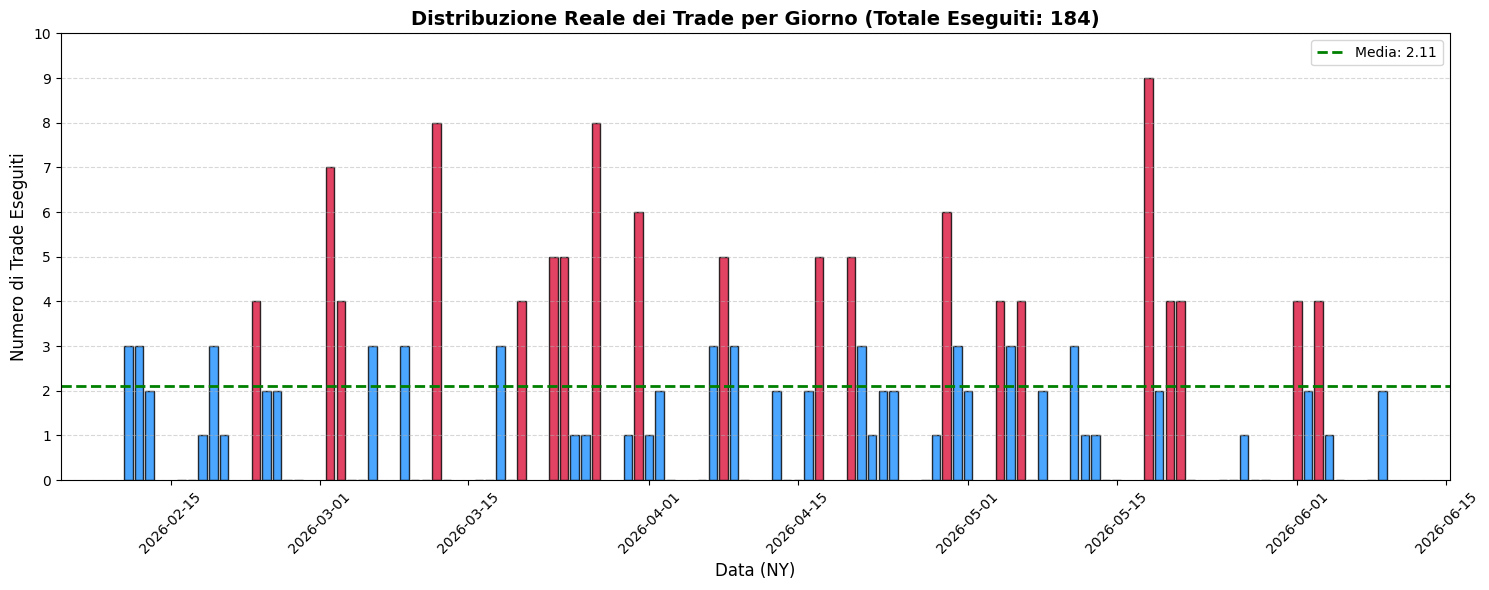

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Controllo sicurezza
if 'df_sweeps' not in globals():
    raise NameError("Errore: Variabile 'df_sweeps' non trovata. Esegui le celle precedenti del backtest!")

print("--- ANALISI DISTRIBUZIONE FREQUENZA: Volatility Clustering (SENZA FILTRO) ---")

# 1. Prendiamo TUTTI i trade eseguiti in modo sicuro
# Controlliamo se la colonna 'Esito' esiste (se hai già fatto girare il motore di esecuzione)
if 'Esito' in df_sweeps.columns:
    df_eseguiti = df_sweeps[df_sweeps['Esito'] != 'MISSED_PULLBACK'].copy()
else:
    df_eseguiti = df_sweeps.copy()
    print("⚠️ Nota: Colonna 'Esito' non ancora calcolata. Mostro la distribuzione di tutti i segnali filtrati.")

# 2. Estraiamo la Data di Wall Street
df_eseguiti['Datetime_Safe'] = pd.to_datetime(df_eseguiti['Datetime_UTC'], utc=True)
df_eseguiti['NY_Time'] = df_eseguiti['Datetime_Safe'].dt.tz_convert('America/New_York')
df_eseguiti['Data'] = df_eseguiti['NY_Time'].dt.date

# 3. Contiamo i trade per ogni singolo giorno
conteggio_giornaliero = df_eseguiti.groupby('Data').size()

# 4. Riempiamo i "Giorni Vuoti" (Dove il bot ha fatto 0 trade)
# Creiamo un calendario di soli giorni lavorativi (Business Days = 'B') dal primo all'ultimo trade
calendario_completo = pd.date_range(start=conteggio_giornaliero.index.min(), 
                                    end=conteggio_giornaliero.index.max(), 
                                    freq='B').date

conteggio_reale = conteggio_giornaliero.reindex(calendario_completo, fill_value=0)

# 5. Calcolo Statistiche
tot_giorni = len(conteggio_reale)
tot_grezzi = len(df_sweeps)
tot_eseguiti = len(df_eseguiti)
media_trade = conteggio_reale.mean()
massimo_trade = conteggio_reale.max()
giorni_zero = (conteggio_reale == 0).sum()

print(f"Giorni di borsa analizzati: {tot_giorni}")
print(f"📡 Totale Segnali Grezzi Trovati: {tot_grezzi}")
print(f"✅ Totale Trade Effettivamente Eseguiti: {tot_eseguiti}")
print(f"---------------------------------------------------")
print(f"📊 Media matematica: {media_trade:.2f} trade / giorno")
print(f"🔥 Picco massimo in un giorno: {massimo_trade} trade")
print(f"🏜️ Giorni con 0 trade: {giorni_zero} giorni ({(giorni_zero/tot_giorni)*100:.1f}%)")

# 6. Generazione Grafico
plt.figure(figsize=(15, 6))

# Creiamo le barre. Rosse per i giorni frenetici (>3), blu per i giorni normali
colori = ['crimson' if x > 3 else 'dodgerblue' for x in conteggio_reale.values]

plt.bar(conteggio_reale.index, conteggio_reale.values, color=colori, edgecolor='black', alpha=0.8)
plt.axhline(media_trade, color='green', linestyle='--', linewidth=2, label=f'Media: {media_trade:.2f}')

plt.title(f'Distribuzione Reale dei Trade per Giorno (Totale Eseguiti: {tot_eseguiti})', fontsize=14, fontweight='bold')
plt.xlabel('Data (NY)', fontsize=12)
plt.ylabel('Numero di Trade Eseguiti', fontsize=12)
plt.yticks(np.arange(0, massimo_trade + 2, 1)) # Scala asse Y a numeri interi
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
import pandas as pd
import numpy as np
import os

# Controlli di sicurezza per assicurarsi che i dati siano in memoria
if 'df_sweeps' not in globals() or 'df' not in globals():
    raise NameError("Errore: Variabili non trovate. Esegui prima i blocchi del setup!")

print("--- GENERAZIONE DATASET STORICO (BACKTEST CSV) ---")
print("Allineamento formato dati con NinjaTrader 8...")

# 1. Prendiamo TUTTI i trade eseguiti (SENZA FILTRO MACRO)
df_eseguiti = df_sweeps[df_sweeps['Esito'] != 'MISSED_PULLBACK'].copy()

# Parametri del setup
PB = 0.50
TP = 1.00
SL = 1.50
TIME_STOP_SEC = 20

backtest_trades = []

for _, row in df_eseguiti.iterrows():
    t_burst = row['Datetime_UTC']
    direzione_int = row['Signal_Imbalance']
    direzione_str = 'LONG' if direzione_int == 1 else 'SHORT'
    
    # Recuperiamo il picco esatto originale (già presente in df_sweeps)
    prezzo_picco = row['Price']
    
    # Ricalcoliamo l'entrata esatta al millisecondo
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    if finestra_pullback.empty: continue
        
    t_entrata = None
    prezzo_entrata = None
    if direzione_int == 1:
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else:
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
            
    if not t_entrata: continue
        
    # Ricalcoliamo l'uscita esatta
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    if finestra_trade.empty: continue
        
    t_uscita = None
    prezzo_uscita = None
    esito = 'TIME_STOP'
    
    if direzione_int == 1: # GESTIONE LONG
        hit_tp = (finestra_trade['Price'] >= prezzo_entrata + TP).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + TP).any() else None
        hit_sl = (finestra_trade['Price'] <= prezzo_entrata - SL).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - SL).any() else None
        
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
            prezzo_uscita = prezzo_entrata + TP if esito == 'WIN' else prezzo_entrata - SL
        elif hit_tp: 
            t_uscita = hit_tp; esito = 'WIN'; prezzo_uscita = prezzo_entrata + TP
        elif hit_sl: 
            t_uscita = hit_sl; esito = 'LOSS'; prezzo_uscita = prezzo_entrata - SL
        else:
            t_uscita = finestra_trade.index[-1]
            prezzo_uscita = finestra_trade['Price'].iloc[-1]
            
    else: # GESTIONE SHORT
        hit_tp = (finestra_trade['Price'] <= prezzo_entrata - TP).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - TP).any() else None
        hit_sl = (finestra_trade['Price'] >= prezzo_entrata + SL).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + SL).any() else None
        
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
            prezzo_uscita = prezzo_entrata - TP if esito == 'WIN' else prezzo_entrata + SL
        elif hit_tp: 
            t_uscita = hit_tp; esito = 'WIN'; prezzo_uscita = prezzo_entrata - TP
        elif hit_sl: 
            t_uscita = hit_sl; esito = 'LOSS'; prezzo_uscita = prezzo_entrata + SL
        else:
            t_uscita = finestra_trade.index[-1]
            prezzo_uscita = finestra_trade['Price'].iloc[-1]
            
    if t_uscita:
        durata_sec = (t_uscita - t_entrata).total_seconds()
        
        # Calcolo PnL Punti (come fa NinjaTrader)
        if direzione_str == 'LONG':
            pnl_punti = prezzo_uscita - prezzo_entrata
        else:
            pnl_punti = prezzo_entrata - prezzo_uscita
            
        # Formattiamo l'ora esatta di uscita in formato New York (come NT8)
        t_uscita_ny = t_uscita.tz_convert('America/New_York').strftime('%Y-%m-%d %H:%M:%S')
        
        backtest_trades.append({
            'Datetime_NY': t_uscita_ny,
            'Direzione': direzione_str,
            'Prezzo_Ingresso': round(prezzo_entrata, 2),
            'Prezzo_Uscita': round(prezzo_uscita, 2),
            'PnL_Punti': round(pnl_punti, 2),
            'Durata_Sec': round(durata_sec, 1),
            'Esito': esito
        })

# Creiamo il DataFrame e lo salviamo
df_csv = pd.DataFrame(backtest_trades)

# Salvataggio nel percorso corrente
nome_file = "Backtest_Trades_Log.csv"
df_csv.to_csv(nome_file, index=False)

print(f"✅ FILE CREATO CON SUCCESSO!")
print(f"Nome file: {nome_file}")
print(f"Totale righe salvate: {len(df_csv)}")
print("\nPrime 5 righe del file (Stesso formato di NinjaTrader):")
display(df_csv.head())

--- GENERAZIONE DATASET STORICO (BACKTEST CSV) ---
Allineamento formato dati con NinjaTrader 8...
✅ FILE CREATO CON SUCCESSO!
Nome file: Backtest_Trades_Log.csv
Totale righe salvate: 184

Prime 5 righe del file (Stesso formato di NinjaTrader):


,Datetime_NY,Direzione,Prezzo_Ingresso,Prezzo_Uscita,PnL_Punti,Durata_Sec,Esito
0,2026-02-11 16:15:00,SHORT,6957.00,6956.00,1.0,1.0,WIN
1,2026-02-11 16:15:21,LONG,6958.00,6956.50,-1.5,3.0,LOSS
2,2026-02-11 16:53:07,LONG,6957.50,6958.50,1.0,5.0,WIN
3,2026-02-12 16:08:14,LONG,6967.00,6965.50,-1.5,20.0,LOSS
4,2026-02-12 17:12:28,LONG,6900.75,6901.75,1.0,0.0,WIN


In [16]:
import pandas as pd
import numpy as np
import time
import platform
import os

print("--- 🔬 LABORATORIO QUANT: GRID SEARCH 'TRAPPOLA DIREZIONALITÀ' (OTTIMIZZATA) ---")
start_time = time.time()

# --- 1. CARICAMENTO DATI ---
sistema_operativo = platform.system()
if sistema_operativo == "Windows":
    percorso_parquet = r"C:\Users\Leona\source\repos\QuantEdge_Project\data\processed\es_master_4months.parquet"
else:
    percorso_parquet = "/Users/leonardosposato/Documents/git/QuantEdge_Project/data/processed/es_master_4months.parquet"

print(f"Caricamento dataset da {percorso_parquet}...")
df = pd.read_parquet(percorso_parquet).dropna(subset=['Price', 'Volume', 'Delta'])

if df.index.name != 'Datetime_UTC':
    df['Datetime_UTC'] = pd.to_datetime(df['Datetime_UTC'], utc=True)
    df = df.set_index('Datetime_UTC').sort_index()

# --- 2. SCANNER V8 (Imbalance 2s) ---
print("Scansione Imbalance (Soglia 800 vol / 0.70 Delta)...")
FINESTRA_SEC = '2s'
df['Rolling_Vol_2s'] = df['Volume'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Delta_2s'] = df['Delta'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Max_2s'] = df['Price'].rolling(window=FINESTRA_SEC).max()
df['Rolling_Min_2s'] = df['Price'].rolling(window=FINESTRA_SEC).min()
df['Price_Range_2s'] = df['Rolling_Max_2s'] - df['Rolling_Min_2s']
df['Delta_Ratio'] = np.where(df['Rolling_Vol_2s'] > 0, abs(df['Rolling_Delta_2s']) / df['Rolling_Vol_2s'], 0)

cond_long = (df['Rolling_Vol_2s'] >= 800) & (df['Rolling_Delta_2s'] > 0) & (df['Delta_Ratio'] >= 0.70) & (df['Price_Range_2s'] >= 0.50)
cond_short = (df['Rolling_Vol_2s'] >= 800) & (df['Rolling_Delta_2s'] < 0) & (df['Delta_Ratio'] >= 0.70) & (df['Price_Range_2s'] >= 0.50)

df['Signal_Imbalance'] = np.where(cond_long, 1, np.where(cond_short, -1, 0))
imbalance_signals = df[df['Signal_Imbalance'] != 0].copy()

df.drop(columns=['Rolling_Vol_2s', 'Rolling_Delta_2s', 'Rolling_Max_2s', 'Rolling_Min_2s', 'Price_Range_2s', 'Delta_Ratio', 'Signal_Imbalance'], inplace=True)

# --- 3. COOLDOWN 15S ---
signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None
for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= 15:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)

# --- 4. PRE-CALCOLO INGRESSI (Ottimizzazione velocità) ---
print("Pre-calcolo dei Pullback (Fisso a 0.50 pt)...")
PB = 0.50
trade_eseguiti = []

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    prezzo_picco = sweep['Price']
    
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty: continue
        
    t_entrata = None
    if direzione == 1:
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else:
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]

    if t_entrata:
        trade_eseguiti.append({'t_entrata': t_entrata, 'prezzo_entrata': prezzo_entrata, 'direzione': direzione})

# --- 5. LA GRIGLIA "TRAPPOLA DIREZIONALE" OTTIMIZZATA ---
print(f"Trade eseguiti a mercato: {len(trade_eseguiti)}. Inizio Grid Search Veloce...")

# Parametri Larghi
tp_list = [1.00, 1.50, 2.00, 3.00, 4.00, 5.00]
sl_list = [1.00, 1.50, 2.00, 3.00]
TIME_STOP_SEC = 60 # Alzato a un minuto per dare tempo al trade di correre!
COMMISSIONI_PT = 0.04 

# Inizializziamo il dizionario dei risultati
risultati_dict = {(TP, SL): {'wins': 0, 'losses': 0, 'time_stops': 0, 'pnl': 0.0} for TP in tp_list for SL in sl_list}

# Inversione dei cicli (Loop Inversion): Iteriamo PRIMA sui trade, estraiamo la fetta di dati UNA SOLA VOLTA
for i, trade in enumerate(trade_eseguiti):
    # Contatore di avanzamento per evitare la sensazione di blocco
    if i % 100 == 0 and i > 0:
        print(f"  ...elaborati {i}/{len(trade_eseguiti)} trade...")
        
    t_entrata = trade['t_entrata']
    prezzo_entrata = trade['prezzo_entrata']
    direzione = trade['direzione']
    
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    if finestra_trade.empty:
        for TP in tp_list:
            for SL in sl_list:
                risultati_dict[(TP, SL)]['time_stops'] += 1
                risultati_dict[(TP, SL)]['pnl'] -= COMMISSIONI_PT
        continue

    # Applichiamo tutte le configurazioni alla stessa finestra di dati già tagliata
    for TP in tp_list:
        for SL in sl_list:
            if direzione == 1: # LONG
                target = prezzo_entrata + TP
                stop = prezzo_entrata - SL
                
                hit_tp = (finestra_trade['Price'] >= target).idxmax() if (finestra_trade['Price'] >= target).any() else None
                hit_sl = (finestra_trade['Price'] <= stop).idxmax() if (finestra_trade['Price'] <= stop).any() else None
                
                if hit_tp and hit_sl:
                    if hit_tp < hit_sl: 
                        risultati_dict[(TP, SL)]['wins'] += 1
                        risultati_dict[(TP, SL)]['pnl'] += (TP - COMMISSIONI_PT)
                    else: 
                        risultati_dict[(TP, SL)]['losses'] += 1
                        risultati_dict[(TP, SL)]['pnl'] -= (SL + COMMISSIONI_PT)
                elif hit_tp: 
                    risultati_dict[(TP, SL)]['wins'] += 1
                    risultati_dict[(TP, SL)]['pnl'] += (TP - COMMISSIONI_PT)
                elif hit_sl: 
                    risultati_dict[(TP, SL)]['losses'] += 1
                    risultati_dict[(TP, SL)]['pnl'] -= (SL + COMMISSIONI_PT)
                else: 
                    risultati_dict[(TP, SL)]['time_stops'] += 1
                    risultati_dict[(TP, SL)]['pnl'] += (finestra_trade['Price'].iloc[-1] - prezzo_entrata) - COMMISSIONI_PT

            else: # SHORT
                target = prezzo_entrata - TP
                stop = prezzo_entrata + SL
                
                hit_tp = (finestra_trade['Price'] <= target).idxmax() if (finestra_trade['Price'] <= target).any() else None
                hit_sl = (finestra_trade['Price'] >= stop).idxmax() if (finestra_trade['Price'] >= stop).any() else None
                
                if hit_tp and hit_sl:
                    if hit_tp < hit_sl: 
                        risultati_dict[(TP, SL)]['wins'] += 1
                        risultati_dict[(TP, SL)]['pnl'] += (TP - COMMISSIONI_PT)
                    else: 
                        risultati_dict[(TP, SL)]['losses'] += 1
                        risultati_dict[(TP, SL)]['pnl'] -= (SL + COMMISSIONI_PT)
                elif hit_tp: 
                    risultati_dict[(TP, SL)]['wins'] += 1
                    risultati_dict[(TP, SL)]['pnl'] += (TP - COMMISSIONI_PT)
                elif hit_sl: 
                    risultati_dict[(TP, SL)]['losses'] += 1
                    risultati_dict[(TP, SL)]['pnl'] -= (SL + COMMISSIONI_PT)
                else: 
                    risultati_dict[(TP, SL)]['time_stops'] += 1
                    risultati_dict[(TP, SL)]['pnl'] += (prezzo_entrata - finestra_trade['Price'].iloc[-1]) - COMMISSIONI_PT

# Convertiamo i risultati raccolti nel dizionario in un comodo DataFrame
risultati_lista = []
for (TP, SL), stats in risultati_dict.items():
    tot = stats['wins'] + stats['losses'] + stats['time_stops']
    win_rate = (stats['wins'] / tot) * 100 if tot > 0 else 0
    risultati_lista.append({
        'Take_Profit': f"{TP:.2f} pt",
        'Stop_Loss': f"{SL:.2f} pt",
        'Net_PnL': round(stats['pnl'], 2),
        'Win_Rate_%': round(win_rate, 2),
        'Vittorie': stats['wins'],
        'Sconfitte': stats['losses'],
        'Time_Stops': stats['time_stops']
    })

df_risultati = pd.DataFrame(risultati_lista).sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"\n=======================================================")
print(f"📊 RISULTATI GRID SEARCH: TP LARGHI vs TP STRETTI")
print(f"=======================================================")
print(f"Tempo di calcolo: {(time.time() - start_time):.2f} sec")
display(df_risultati.head(15))

--- 🔬 LABORATORIO QUANT: GRID SEARCH 'TRAPPOLA DIREZIONALITÀ' (OTTIMIZZATA) ---
Caricamento dataset da C:\Users\Leona\source\repos\QuantEdge_Project\data\processed\es_master_4months.parquet...
Scansione Imbalance (Soglia 800 vol / 0.70 Delta)...
Pre-calcolo dei Pullback (Fisso a 0.50 pt)...
Trade eseguiti a mercato: 236. Inizio Grid Search Veloce...
  ...elaborati 100/236 trade...
  ...elaborati 200/236 trade...

📊 RISULTATI GRID SEARCH: TP LARGHI vs TP STRETTI
Tempo di calcolo: 70.17 sec


,Take_Profit,Stop_Loss,Net_PnL,Win_Rate_%,Vittorie,Sconfitte,Time_Stops
0,5.00 pt,3.00 pt,143.06,16.10,38,49,149
1,2.00 pt,3.00 pt,134.81,58.05,137,37,62
2,2.00 pt,2.00 pt,128.06,55.51,131,59,46
3,3.00 pt,3.00 pt,127.06,37.71,89,46,101
4,1.50 pt,3.00 pt,125.06,69.92,165,31,40
5,1.00 pt,2.00 pt,122.56,82.63,195,29,12
6,4.00 pt,3.00 pt,120.56,22.03,52,49,135
7,5.00 pt,2.00 pt,120.31,13.98,33,80,123
8,3.00 pt,2.00 pt,119.81,35.59,84,73,79
9,1.50 pt,2.00 pt,119.81,67.37,159,49,28


In [17]:
import pandas as pd
import numpy as np
import time
import platform
import os

print("--- 🔬 LABORATORIO QUANT: OTTIMIZZAZIONE TIME STOP ---")
start_time = time.time()

# --- 1. CARICAMENTO DATI ---
sistema_operativo = platform.system()
if sistema_operativo == "Windows":
    percorso_parquet = r"C:\Users\Leona\source\repos\QuantEdge_Project\data\processed\es_master_4months.parquet"
else:
    percorso_parquet = "/Users/leonardosposato/Documents/git/QuantEdge_Project/data/processed/es_master_4months.parquet"

print(f"Caricamento dataset da {percorso_parquet}...")
df = pd.read_parquet(percorso_parquet).dropna(subset=['Price', 'Volume', 'Delta'])

if df.index.name != 'Datetime_UTC':
    df['Datetime_UTC'] = pd.to_datetime(df['Datetime_UTC'], utc=True)
    df = df.set_index('Datetime_UTC').sort_index()

# --- 2. SCANNER V8 (Imbalance 2s) ---
print("Scansione Imbalance in corso...")
FINESTRA_SEC = '2s'
df['Rolling_Vol_2s'] = df['Volume'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Delta_2s'] = df['Delta'].rolling(window=FINESTRA_SEC).sum()
df['Rolling_Max_2s'] = df['Price'].rolling(window=FINESTRA_SEC).max()
df['Rolling_Min_2s'] = df['Price'].rolling(window=FINESTRA_SEC).min()
df['Price_Range_2s'] = df['Rolling_Max_2s'] - df['Rolling_Min_2s']
df['Delta_Ratio'] = np.where(df['Rolling_Vol_2s'] > 0, abs(df['Rolling_Delta_2s']) / df['Rolling_Vol_2s'], 0)

cond_long = (df['Rolling_Vol_2s'] >= 800) & (df['Rolling_Delta_2s'] > 0) & (df['Delta_Ratio'] >= 0.70) & (df['Price_Range_2s'] >= 0.50)
cond_short = (df['Rolling_Vol_2s'] >= 800) & (df['Rolling_Delta_2s'] < 0) & (df['Delta_Ratio'] >= 0.70) & (df['Price_Range_2s'] >= 0.50)

df['Signal_Imbalance'] = np.where(cond_long, 1, np.where(cond_short, -1, 0))
imbalance_signals = df[df['Signal_Imbalance'] != 0].copy()

df.drop(columns=['Rolling_Vol_2s', 'Rolling_Delta_2s', 'Rolling_Max_2s', 'Rolling_Min_2s', 'Price_Range_2s', 'Delta_Ratio', 'Signal_Imbalance'], inplace=True)

# --- 3. COOLDOWN 15S ---
signals_df = imbalance_signals.reset_index()
valid_sweeps = []
last_sweep_time = None
for idx, row in signals_df.iterrows():
    if last_sweep_time is None or (row['Datetime_UTC'] - last_sweep_time).total_seconds() >= 15:
        valid_sweeps.append(row)
        last_sweep_time = row['Datetime_UTC']

df_sweeps = pd.DataFrame(valid_sweeps)

# --- 4. PRE-CALCOLO INGRESSI ---
print("Calcolo entrate a mercato (Pullback 0.50 pt fisso)...")
PB = 0.50
trade_eseguiti = []

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione = sweep['Signal_Imbalance']
    prezzo_picco = sweep['Price']
    
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty: continue
        
    t_entrata = None
    if direzione == 1:
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else:
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]

    if t_entrata:
        trade_eseguiti.append({'t_entrata': t_entrata, 'prezzo_entrata': prezzo_entrata, 'direzione': direzione})

# --- 5. GRID SEARCH TIME STOP (Fissi: TP 1.00, SL 1.50) ---
print(f"Trade validi: {len(trade_eseguiti)}. Inizio simulazione temporale...")

TP = 1.00
SL = 1.50
COMMISSIONI_PT = 0.04 
time_stop_list = [5, 10, 15, 20, 25, 30, 45, 60, 90, 120] # Secondi

# Inizializzazione dizionario
risultati_dict = {ts: {'wins': 0, 'losses': 0, 'time_stops': 0, 'pnl': 0.0} for ts in time_stop_list}

max_ts = max(time_stop_list)

for i, trade in enumerate(trade_eseguiti):
    if i % 100 == 0 and i > 0:
        print(f"  ...elaborati {i}/{len(trade_eseguiti)} trade...")
        
    t_entrata = trade['t_entrata']
    prezzo_entrata = trade['prezzo_entrata']
    direzione = trade['direzione']
    
    # Estraiamo la finestra massima (120 secondi) una sola volta per trade
    t_scadenza_max = t_entrata + pd.Timedelta(seconds=max_ts)
    finestra_max = df.loc[t_entrata : t_scadenza_max]
    
    for TS in time_stop_list:
        # Ritagliamo la finestra in base al Time Stop corrente
        t_scadenza = t_entrata + pd.Timedelta(seconds=TS)
        finestra_trade = finestra_max[finestra_max.index <= t_scadenza]
        
        if finestra_trade.empty:
            risultati_dict[TS]['time_stops'] += 1
            risultati_dict[TS]['pnl'] -= COMMISSIONI_PT
            continue

        if direzione == 1: # LONG
            target = prezzo_entrata + TP
            stop = prezzo_entrata - SL
            
            hit_tp = (finestra_trade['Price'] >= target).idxmax() if (finestra_trade['Price'] >= target).any() else None
            hit_sl = (finestra_trade['Price'] <= stop).idxmax() if (finestra_trade['Price'] <= stop).any() else None
            
            if hit_tp and hit_sl:
                if hit_tp < hit_sl: 
                    risultati_dict[TS]['wins'] += 1; risultati_dict[TS]['pnl'] += (TP - COMMISSIONI_PT)
                else: 
                    risultati_dict[TS]['losses'] += 1; risultati_dict[TS]['pnl'] -= (SL + COMMISSIONI_PT)
            elif hit_tp: 
                risultati_dict[TS]['wins'] += 1; risultati_dict[TS]['pnl'] += (TP - COMMISSIONI_PT)
            elif hit_sl: 
                risultati_dict[TS]['losses'] += 1; risultati_dict[TS]['pnl'] -= (SL + COMMISSIONI_PT)
            else: 
                risultati_dict[TS]['time_stops'] += 1
                risultati_dict[TS]['pnl'] += (finestra_trade['Price'].iloc[-1] - prezzo_entrata) - COMMISSIONI_PT

        else: # SHORT
            target = prezzo_entrata - TP
            stop = prezzo_entrata + SL
            
            hit_tp = (finestra_trade['Price'] <= target).idxmax() if (finestra_trade['Price'] <= target).any() else None
            hit_sl = (finestra_trade['Price'] >= stop).idxmax() if (finestra_trade['Price'] >= stop).any() else None
            
            if hit_tp and hit_sl:
                if hit_tp < hit_sl: 
                    risultati_dict[TS]['wins'] += 1; risultati_dict[TS]['pnl'] += (TP - COMMISSIONI_PT)
                else: 
                    risultati_dict[TS]['losses'] += 1; risultati_dict[TS]['pnl'] -= (SL + COMMISSIONI_PT)
            elif hit_tp: 
                risultati_dict[TS]['wins'] += 1; risultati_dict[TS]['pnl'] += (TP - COMMISSIONI_PT)
            elif hit_sl: 
                risultati_dict[TS]['losses'] += 1; risultati_dict[TS]['pnl'] -= (SL + COMMISSIONI_PT)
            else: 
                risultati_dict[TS]['time_stops'] += 1
                risultati_dict[TS]['pnl'] += (prezzo_entrata - finestra_trade['Price'].iloc[-1]) - COMMISSIONI_PT

# --- 6. REPORT RISULTATI ---
risultati_lista = []
for TS, stats in risultati_dict.items():
    tot = stats['wins'] + stats['losses'] + stats['time_stops']
    win_rate = (stats['wins'] / tot) * 100 if tot > 0 else 0
    risultati_lista.append({
        'Time_Stop': f"{TS} sec",
        'Net_PnL': round(stats['pnl'], 2),
        'Win_Rate_%': round(win_rate, 2),
        'Vittorie': stats['wins'],
        'Sconfitte': stats['losses'],
        'Uscite_Tempo': stats['time_stops']
    })

df_risultati = pd.DataFrame(risultati_lista).sort_values(by='Net_PnL', ascending=False).reset_index(drop=True)

print(f"\n=======================================================")
print(f"📊 RISULTATI GRID SEARCH: OTTIMIZZAZIONE TIME STOP")
print(f"   (Fissi: TP 1.00 pt | SL 1.50 pt | PB 0.50 pt)")
print(f"=======================================================")
print(f"Tempo di calcolo: {(time.time() - start_time):.2f} sec")
display(df_risultati)

--- 🔬 LABORATORIO QUANT: OTTIMIZZAZIONE TIME STOP ---
Caricamento dataset da C:\Users\Leona\source\repos\QuantEdge_Project\data\processed\es_master_4months.parquet...
Scansione Imbalance in corso...
Calcolo entrate a mercato (Pullback 0.50 pt fisso)...
Trade validi: 236. Inizio simulazione temporale...
  ...elaborati 100/236 trade...
  ...elaborati 200/236 trade...

📊 RISULTATI GRID SEARCH: OTTIMIZZAZIONE TIME STOP
   (Fissi: TP 1.00 pt | SL 1.50 pt | PB 0.50 pt)
Tempo di calcolo: 72.27 sec


,Time_Stop,Net_PnL,Win_Rate_%,Vittorie,Sconfitte,Uscite_Tempo
0,45 sec,121.06,78.81,186,36,14
1,10 sec,119.56,69.92,165,21,50
2,30 sec,119.56,77.97,184,33,19
3,15 sec,118.81,72.46,171,25,40
4,25 sec,116.81,75.85,179,32,25
5,20 sec,116.56,74.58,176,30,30
6,120 sec,115.56,80.93,191,44,1
7,60 sec,114.56,79.24,187,40,9
8,90 sec,113.56,80.51,190,44,2
9,5 sec,110.81,63.98,151,15,70


In [18]:
import pandas as pd
import numpy as np
import os
import time

# Controlli di sicurezza per assicurarsi che i dati siano in memoria
if 'df_sweeps' not in globals() or 'df' not in globals():
    raise NameError("Errore: Variabili non trovate. Esegui prima i blocchi dello scanner V8!")

print("--- 🏆 GENERAZIONE DATASET STORICO DEFINITIVO (V8 a 45 SECONDI) ---")
start_time = time.time()

# I NOSTRI PARAMETRI D'ORO
PB = 0.50             # Pullback
TP = 1.00             # Take Profit
SL = 1.50             # Stop Loss
TIME_STOP_SEC = 45    # Il nuovo time stop ottimizzato!
COMMISSIONI_PT = 0.04 # 2$ Round Turn (Topstep)

backtest_trades = []
trade_eseguiti = 0
wins = 0
losses = 0
time_stops = 0
pnl_netto_totale = 0.0

for _, sweep in df_sweeps.iterrows():
    t_burst = sweep['Datetime_UTC']
    direzione_int = sweep['Signal_Imbalance']
    direzione_str = 'LONG' if direzione_int == 1 else 'SHORT'
    
    # 1. Recuperiamo il picco esatto battuto dal Future (Questo sblocca i 236 trade)
    prezzo_picco = sweep['Price']
    
    # 2. Ricalcoliamo l'entrata esatta al millisecondo
    t_fine_pullback = t_burst + pd.Timedelta(seconds=3.0)
    finestra_pullback = df.loc[t_burst : t_fine_pullback]
    
    if finestra_pullback.empty: continue
        
    t_entrata = None
    prezzo_entrata = None
    
    if direzione_int == 1: # LONG
        hit_pb = finestra_pullback[finestra_pullback['Price'] <= (prezzo_picco - PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
    else: # SHORT
        hit_pb = finestra_pullback[finestra_pullback['Price'] >= (prezzo_picco + PB)]
        if not hit_pb.empty: t_entrata = hit_pb.index[0]; prezzo_entrata = hit_pb['Price'].iloc[0]
            
    if not t_entrata: continue # Trade non eseguito dal mercato
        
    trade_eseguiti += 1
        
    # 3. Ricalcoliamo l'uscita esatta con finestra a 45 SECONDI
    t_scadenza = t_entrata + pd.Timedelta(seconds=TIME_STOP_SEC)
    finestra_trade = df.loc[t_entrata : t_scadenza]
    
    if finestra_trade.empty: 
        time_stops += 1
        pnl_netto_totale -= COMMISSIONI_PT
        continue
        
    t_uscita = None
    prezzo_uscita = None
    esito = 'TIME_STOP'
    
    if direzione_int == 1: # GESTIONE LONG
        hit_tp = (finestra_trade['Price'] >= prezzo_entrata + TP).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + TP).any() else None
        hit_sl = (finestra_trade['Price'] <= prezzo_entrata - SL).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - SL).any() else None
        
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
            prezzo_uscita = prezzo_entrata + TP if esito == 'WIN' else prezzo_entrata - SL
        elif hit_tp: 
            t_uscita = hit_tp; esito = 'WIN'; prezzo_uscita = prezzo_entrata + TP
        elif hit_sl: 
            t_uscita = hit_sl; esito = 'LOSS'; prezzo_uscita = prezzo_entrata - SL
        else:
            t_uscita = finestra_trade.index[-1]
            prezzo_uscita = finestra_trade['Price'].iloc[-1]
            
    else: # GESTIONE SHORT
        hit_tp = (finestra_trade['Price'] <= prezzo_entrata - TP).idxmax() if (finestra_trade['Price'] <= prezzo_entrata - TP).any() else None
        hit_sl = (finestra_trade['Price'] >= prezzo_entrata + SL).idxmax() if (finestra_trade['Price'] >= prezzo_entrata + SL).any() else None
        
        if hit_tp and hit_sl: 
            t_uscita = min(hit_tp, hit_sl)
            esito = 'WIN' if hit_tp < hit_sl else 'LOSS'
            prezzo_uscita = prezzo_entrata - TP if esito == 'WIN' else prezzo_entrata + SL
        elif hit_tp: 
            t_uscita = hit_tp; esito = 'WIN'; prezzo_uscita = prezzo_entrata - TP
        elif hit_sl: 
            t_uscita = hit_sl; esito = 'LOSS'; prezzo_uscita = prezzo_entrata + SL
        else:
            t_uscita = finestra_trade.index[-1]
            prezzo_uscita = finestra_trade['Price'].iloc[-1]
            
    if t_uscita:
        durata_sec = (t_uscita - t_entrata).total_seconds()
        
        # Calcolo PnL Punti (Lordo)
        if direzione_str == 'LONG': pnl_punti = prezzo_uscita - prezzo_entrata
        else: pnl_punti = prezzo_entrata - prezzo_uscita
            
        # Aggiornamento contatori per il Report
        if esito == 'WIN': 
            wins += 1; pnl_netto_totale += (pnl_punti - COMMISSIONI_PT)
        elif esito == 'LOSS': 
            losses += 1; pnl_netto_totale += (pnl_punti - COMMISSIONI_PT)
        else: 
            time_stops += 1; pnl_netto_totale += (pnl_punti - COMMISSIONI_PT)
            
        # Formattiamo l'ora esatta di uscita in formato New York per la Dashboard
        t_uscita_ny = t_uscita.tz_convert('America/New_York').strftime('%Y-%m-%d %H:%M:%S')
        
        backtest_trades.append({
            'Datetime_NY': t_uscita_ny,
            'Direzione': direzione_str,
            'Prezzo_Ingresso': round(prezzo_entrata, 2),
            'Prezzo_Uscita': round(prezzo_uscita, 2),
            'PnL_Punti': round(pnl_punti - COMMISSIONI_PT, 2), # Salviamo il PnL Netto nel CSV
            'Durata_Sec': round(durata_sec, 1),
            'Esito': esito
        })

# --- 4. GENERAZIONE FILE CSV ---
df_csv = pd.DataFrame(backtest_trades)
nome_file = "Backtest_Trades_Log.csv"
df_csv.to_csv(nome_file, index=False)

# --- 5. STAMPA REPORT DEFINITIVO ---
win_rate = (wins / trade_eseguiti) * 100 if trade_eseguiti > 0 else 0

print(f"\n=======================================================")
print(f"📊 REPORT DEFINITIVO (FUTURE PURO | 45s TIME STOP)")
print(f"=======================================================")
print(f"Trade ESEGUITI a Mercato:    {trade_eseguiti}")
print(f"-------------------------------------------------------")
print(f"🏆 Vittorie (TP Hit):         {wins}")
print(f"❌ Sconfitte (SL Hit):        {losses}")
print(f"⏱️ Uscite per Tempo (45s):    {time_stops}")
print(f"-------------------------------------------------------")
print(f"🎯 WIN RATE EFFETTIVO:        {win_rate:.2f}%")
print(f"💰 PnL Netto Totale:          {pnl_netto_totale:.2f} pt")
print(f"💵 PnL Netto (1 Contratto):   ${pnl_netto_totale * 50:,.2f}")
print(f"=======================================================")
print(f"✅ File generato con successo: '{nome_file}'")
print(f"Ora la tua Dashboard Streamlit leggerà la 'Golden Copy' perfetta!")

--- 🏆 GENERAZIONE DATASET STORICO DEFINITIVO (V8 a 45 SECONDI) ---

📊 REPORT DEFINITIVO (FUTURE PURO | 45s TIME STOP)
Trade ESEGUITI a Mercato:    236
-------------------------------------------------------
🏆 Vittorie (TP Hit):         186
❌ Sconfitte (SL Hit):        36
⏱️ Uscite per Tempo (45s):    14
-------------------------------------------------------
🎯 WIN RATE EFFETTIVO:        78.81%
💰 PnL Netto Totale:          121.06 pt
💵 PnL Netto (1 Contratto):   $6,053.00
✅ File generato con successo: 'Backtest_Trades_Log.csv'
Ora la tua Dashboard Streamlit leggerà la 'Golden Copy' perfetta!
